<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 3</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

<img src="./img/consigna.png" width="800" />

***

## Índice

> **Nota:** los hipervínculos funcionan correctamente en JupyterLab y VS Code abiertos localmente. Si el notebook se visualiza desde **GitHub**, los links pueden no redirigir.

1. [Punto 1 — Función transferencia (aproximación de Chebyshev)](#p1)
2. [Punto 2 — Respuesta en frecuencia y diagrama de polos y ceros](#p2)
3. [Punto 3 — Red normalizada con estructuras pasivas y buffers activos](#p3)
4. [Punto 4 — Reemplazo de inductores por GIC de Antoniou](#p4)
5. [Punto 5 — SOS pasiva → MFB pasa altos + análisis de sensibilidad](#p5)
6. Punto 6 — Verificación con LTSpice

   > **Aclaración:** las verificaciones en LTSpice se realizan dentro del punto correspondiente, a continuación de cada desarrollo.

**Bonus:**
- [Bonus 1 — Red de mismo orden con aproximación de máxima planicidad](#b1)
- [Bonus 2 — Verificación numérica con `scipy`](#b2)

In [3]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt
from IPython.display import display, Math

import pytc2
print(f'Versión pytc2: {pytc2.__version__}')

from pytc2.sistemas_lineales import (bodePlot, pzmap, analyze_sys,
                                     tf2sos_analog, pretty_print_lti,
                                     pretty_print_bicuad_omegayq,
                                     pretty_print_SOS, parametrize_sos,
                                     GroupDelay, plot_plantilla)
from pytc2.general import (print_subtitle, print_latex, to_latex,
                            Chebyshev_polynomials, a_equal_b_latex_s)

plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})

s = sp.Symbol('s', complex=True)

# ── helpers simbólicos (igual que en TS2) ─────────────────────────────────────
def normalize(T):
    num, den = sp.fraction(sp.cancel(T))
    den_exp = sp.expand(den)
    a2 = den_exp.coeff(s, 2)
    if a2 == 0:
        a2 = den_exp.coeff(s, 1)
        num_n = sp.simplify(sp.expand(num) / a2)
        den_n = s + sp.simplify(den_exp.coeff(s, 0) / a2)
    else:
        num_n = sp.simplify(sp.expand(num) / a2)
        den_n = s**2 + sp.simplify(den_exp.coeff(s,1)/a2)*s + sp.simplify(den_exp.coeff(s,0)/a2)
    return num_n / den_n

def extract_biquad_params(T, filter_type):
    num, den = sp.fraction(sp.cancel(T))
    num_e = sp.expand(num); den_e = sp.expand(den)
    a2 = den_e.coeff(s,2); a1 = den_e.coeff(s,1); a0 = den_e.coeff(s,0)
    n2 = num_e.coeff(s,2); n1 = num_e.coeff(s,1); n0 = num_e.coeff(s,0)
    w0sq = sp.simplify(a0/a2); w0Q = sp.simplify(a1/a2)
    w0_  = sp.sqrt(w0sq); Q_  = sp.simplify(w0_ / w0Q)
    if   filter_type == 'LPF': K_ = sp.simplify(n0/a0)
    elif filter_type == 'HPF': K_ = sp.simplify(n2/a2)
    elif filter_type == 'BPF': K_ = sp.simplify(n1/a1)
    return sp.simplify(K_), sp.simplify(w0_), sp.simplify(Q_)

Versión pytc2: 0.2.1


<a id="p1"></a>

***

## Punto 1 — Función transferencia (aproximación de Chebyshev)

### Resolución manuscrita

Originales: `p1_hoja_1.jpg` a `p1_hoja_6.jpg` en [img/](./img/)

<img src="./img/p1_hoja_1.jpg" width="450" />
<img src="./img/p1_hoja_2.jpg" width="450" />
<img src="./img/p1_hoja_3.jpg" width="450" />
<img src="./img/p1_hoja_4.jpg" width="450" />
<img src="./img/p1_hoja_5.jpg" width="450" />
<img src="./img/p1_hoja_6.jpg" width="450" />

---

### Transcripción

#### 1.1 Identificación de la plantilla

| $\alpha_{\max}$ [dB] | $\alpha_{\min}$ [dB] | $f_p$ [kHz] | $f_s$ [kHz] |
|:---:|:---:|:---:|:---:|
| 0.5 | 30 | 40 | 10 |

Como $f_s < f_p$, la banda de paso está en **altas frecuencias** → **filtro pasa altos**.

$$\omega_p = 2\pi f_p = 2\pi \cdot 40\,\text{kHz}, \qquad \omega_s = 2\pi f_s = 2\pi \cdot 10\,\text{kHz}$$

#### 1.2 Normalización y transformación LP → HP

Se normaliza por $\Omega_\omega = \omega_p$, quedando $\omega_p^{(\text{norm})} = 1$. La frecuencia de rechazo normalizada es:

$$\Omega_s = \frac{\omega_s}{\omega_p} = \frac{f_s}{f_p} = \frac{10}{40} = 0{,}25$$

Aplicando el núcleo de transformación HPF $\leftarrow$ LPF ($s \to 1/s$):

$$\Omega_s^{(\text{LP})} = \frac{1}{\Omega_s} = 4$$

#### 1.3 Parámetro $\varepsilon^2$ y orden $n$

$$\varepsilon^2 = 10^{\,\alpha_{\max}/10} - 1 = 10^{0{,}05} - 1 = \boxed{0{,}12202}$$

Iterando $\alpha_n = 10\log_{10}(1 + \varepsilon^2\cosh^2(n\cosh^{-1}(4)))$ hasta $\alpha_n \geq 30\,\text{dB}$:

| $n$ | $\alpha_n$ [dB] |
|:---:|:---:|
| 1 | 4,70 |
| 2 | 20,72 |
| **3** | **38,61 ✓** |

$$\Rightarrow \boxed{n = 3}, \qquad C_3(\Omega) = 2\Omega\,C_2 - C_1 = 4\Omega^3 - 3\Omega$$

#### 1.4 $T(s)\cdot T(-s)$ — expansión del denominador

Con $C_3(\Omega) = 4\Omega^3-3\Omega$ y la sustitución $\Omega \to s/j$:

$$T(s)\cdot T(-s) = \frac{-0{,}5122}{s^6 + 1{,}5\,s^4 + 0{,}5625\,s^2 - 0{,}5122}$$

Se propone $T(s) = \dfrac{A}{s^3+Bs^2+Cs+A}$, con $T(0)=1$. Entonces $T(-s) = \dfrac{A}{-s^3+Bs^2-Cs+A}$ y:

$$T(s)\cdot T(-s) = \frac{A^2}{(s^3+Bs^2+Cs+A)(-s^3+Bs^2-Cs+A)}$$

Expandiendo el denominador término a término:

$$\begin{array}{rcl}
&& (s^3+Bs^2+Cs+A)(-s^3+Bs^2-Cs+A)\\[4pt]
&=& -s^6 + Bs^5 - Cs^4 + As^3 \\
&& -Bs^5 + B^2s^4 - BCs^3 + ABs^2 \\
&& -Cs^4 + BCs^3 - C^2s^2 + ACs \\
&& -As^3 + ABs^2 - ACs + A^2
\end{array}$$

Agrupando (los términos impares cancelan):

$$= -s^6 + \underbrace{(B^2-2C)}_{s^4}\,s^4 + \underbrace{(2AB-C^2)}_{s^2}\,s^2 + A^2$$

Multiplicando por $-1/-1$:

$$\boxed{T(s)\cdot T(-s) = \frac{-A^2}{s^6 + (2C-B^2)\,s^4 + (C^2-2AB)\,s^2 - A^2}}$$

#### 1.5 Sistema de ecuaciones

Igualando coeficiente a coeficiente con el denominador de $T(s)\cdot T(-s)$:

$$A^2 = \frac{1}{16\varepsilon^2} \implies \boxed{A = \frac{1}{4\varepsilon} = 0{,}7157} \tag{3}$$

$$2C - B^2 = \frac{3}{2} \tag{1}$$

$$C^2 - 2AB = \frac{9}{16} \tag{2}$$

#### 1.6 Resolución — cúbica en $B$

De $(1)$:

$$C = \frac{3/2 + B^2}{2} = \frac{3}{4} + \frac{B^2}{2} \tag{4}$$

Sustituyendo $(4)$ en $(2)$, y usando $2AB = 2\cdot\dfrac{1}{4\varepsilon}\cdot B = \dfrac{B}{2\varepsilon}$:

$$\left(\frac{3}{4}+\frac{B^2}{2}\right)^2 - \frac{B}{2\varepsilon} = \frac{9}{16}$$

Expandiendo:

$$\frac{9}{16} + \frac{3B^2}{4} + \frac{B^4}{4} - \frac{B}{2\varepsilon} = \frac{9}{16}$$

$$\frac{B^4}{4} + \frac{3B^2}{4} - \frac{B}{2\varepsilon} = 0$$

Dividiendo por $B$ ($B\neq 0$) y multiplicando por 4:

$$B^3 + 3B = \frac{2}{\varepsilon} = 5{,}7256$$

Las otras dos raíces de esta cúbica son complejas, por lo que la única raíz real es:

$$\boxed{B = 1{,}2529}, \qquad C = \frac{3/2 + 1{,}2529^2}{2} = \boxed{1{,}5349}$$

#### 1.7 Prototipo LP Chebyshev normalizado

$$T_{\text{LP}}(s) = \frac{0{,}7157}{s^3 + 1{,}2529\,s^2 + 1{,}5349\,s + 0{,}7157}$$

Los polos son:

$$s_1 = -0{,}62644, \qquad s_{2,3} = -0{,}31322 \pm j\,1{,}02193$$

El par complejo conjugado se factoriza:

$$(s+\alpha-j\beta)(s+\alpha+j\beta) = s^2 + 2\alpha s + \alpha^2+\beta^2$$

$$= s^2 + 2(0{,}31322)\,s + 0{,}31322^2 + 1{,}02193^2 = s^2 + 0{,}62644\,s + 1{,}14244$$

$$\boxed{T_{\text{LP}}(s) = \frac{0{,}71569}{(s + 0{,}62644)\,(s^2 + 0{,}62644\,s + 1{,}14244)}}$$

#### 1.8 Transformación LP → HP (normalizado, $\omega_p = 1$ rad/s)

Se aplica $s \leftarrow 1/s$:

$$T_{\text{HP}}(s) = T_{\text{LP}}\!\left(\frac{1}{s}\right) = \frac{0{,}71569}{\left(\dfrac{1}{s}+0{,}62644\right)\!\left(\dfrac{1}{s^2}+\dfrac{0{,}62644}{s}+1{,}14244\right)}$$

Multiplicando numerador y denominador por $s^3$:

$$= \frac{0{,}71569\,s^3}{(1+0{,}62644\,s)(1+0{,}62644\,s+1{,}14244\,s^2)}$$

Sacando el factor del coeficiente líder de cada paréntesis:

$$= \frac{0{,}71569\,s^3}{0{,}62644\!\left(s+\dfrac{1}{0{,}62644}\right) \cdot 1{,}14244\!\left(s^2+\dfrac{0{,}62644}{1{,}14244}s+\dfrac{1}{1{,}14244}\right)}$$

Como $0{,}62644 \times 1{,}14244 = 0{,}71569$, la constante cancela:

$$\boxed{T_{\text{HP,\,norm}}(s) = \frac{s^3}{\left(s + 1{,}5963\right)\!\left(s^2 + 0{,}5483\,s + 0{,}8753\right)}}$$

#### 1.9 Desnormalización ($\Omega_\omega = 2\pi \cdot 40\,\text{kHz}$)

Sustitución $s \leftarrow s/\Omega_\omega$, multiplicando por $\Omega_\omega^3$:

$$T(s) = \frac{s^3}{\left(s + 1{,}5963\,\Omega_\omega\right)\!\left(s^2 + 0{,}5483\,\Omega_\omega\,s + 0{,}8753\,\Omega_\omega^2\right)}$$

Con $\Omega_\omega = 2\pi \times 40\,000 = 80\,000\pi\,\text{rad/s}$:

$$1{,}5963 \times 80\,000\pi = \frac{3\,192\,560\,\pi}{25}\,\text{rad/s} \approx 401\,189\,\text{rad/s}$$

$$0{,}5483 \times 80\,000\pi = \frac{219\,320\,\pi}{5}\,\text{rad/s} \approx 137\,814\,\text{rad/s}$$

$$0{,}8753 \times (80\,000\pi)^2 \approx 5{,}529 \times 10^{10}\,\text{(rad/s)}^2$$

$$\boxed{T(s) = \frac{s^3}{\left(s + \dfrac{3\,192\,560\,\pi}{25}\right)\!\left(s^2 + \dfrac{219\,320\,\pi}{5}\,s + 5{,}529 \times 10^{10}\right)}}$$

**Filtro HPF Chebyshev tipo I, $n=3$, $\varepsilon^2=0{,}12202$, $f_p=40\,\text{kHz}$, $f_s=10\,\text{kHz}$.**

---

> ✅ **Verificación Python:** los valores del prototipo LP ($p_1=-0{,}6265$, $p_{2,3}=-0{,}3132\pm j1{,}0219$), la TF HP normalizada y la desnormalización se comprobaron con `scipy.signal.cheb1ap` y `lp2hp_zpk`, obteniendo coincidencia a 4 cifras significativas en todos los parámetros.

In [28]:
def print_sos_params(sos):
    for k, row in enumerate(sos):
        b1, b2, b3 = row[3], row[4], row[5]
        if abs(b1) < 1e-12:
            print(f'    SOS {k+1} (1er orden): polo en σ = {-b3/b2:.6f}')
        else:
            w0 = np.sqrt(b3 / b1)
            Q  = np.sqrt(b1 * b3) / b2
            print(f'    SOS {k+1} (2do orden): ω₀ = {w0:.6f} rad/s,  Q = {Q:.6f}')

# ══════════════════════════════════════════════════════════════════════════════
# PUNTO 1 — Chebyshev HP n=3
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Especificaciones ───────────────────────────────────────────────────────
alpha_max_dB = 0.5     # dB
alpha_min_dB = 30      # dB
fp = 40e3              # Hz
fs = 10e3              # Hz
wp = 2 * np.pi * fp    # rad/s  (norma de frecuencia Ωω)
ws = 2 * np.pi * fs    # rad/s

print_subtitle("Especificaciones")
print(f"  αmax = {alpha_max_dB} dB,  αmin = {alpha_min_dB} dB")
print(f"  fp   = {fp/1e3:.0f} kHz  →  ωp = {wp:.2f} rad/s")
print(f"  fs   = {fs/1e3:.0f} kHz  →  ωs = {ws:.2f} rad/s")

# ── 2. Validación de ε² ───────────────────────────────────────────────────────
print_subtitle("Validación de ε²")

eps2 = 10**(alpha_max_dB / 10) - 1
eps  = np.sqrt(eps2)

# Comprobación inversa: de ε² recuperar αmax
alpha_max_check = 10 * np.log10(1 + eps2)

print(f"  ε²        = 10^(αmax/10) - 1 = 10^({alpha_max_dB}/10) - 1 = {eps2:.8f}")
print(f"  ε         = √ε²              = {eps:.8f}")
print(f"  Verificación: 10·log₁₀(1+ε²) = {alpha_max_check:.4f} dB  (debe ser {alpha_max_dB} dB)")

# ── 3. Determinación del orden n por iteración ───────────────────────────────
print_subtitle('Determinación del orden n')

Omega_s_lp = fp / fs   # = 4  (selectividad del prototipo LP)
print(f'  Ωs(LP) = fp/fs = {fp/1e3:.0f}/{fs/1e3:.0f} = {Omega_s_lp:.1f}')
print(f'  Iterando: αn = 10·log10(1 + ε²·cosh²(n·acosh(Ωs))) hasta αn ≥ αmin = {alpha_min_dB} dB')
print(f"  {'n':>4} | {'αn [dB]':>12} | {'≥ αmin?':>8}")
print(f"  {'-'*32}")

n = None
for n_ord in range(1, 20):
    alpha_n = 10 * np.log10(1 + eps2 * np.cosh(n_ord * np.arccosh(Omega_s_lp))**2)
    if alpha_n >= alpha_min_dB:
        print(f"  {n_ord:>4} | {alpha_n:>12.4f} | ✓  ← elegido")
        n = n_ord
        break
    else:
        print(f"  {n_ord:>4} | {alpha_n:>12.4f} | ✗")

print(f'\n  → n = {n}')

# ── 4. Polinomio de Chebyshev C3 ──────────────────────────────────────────────
print_subtitle("Polinomio de Chebyshev C₃(ω)")
for k in range(n+1):
    Ck = Chebyshev_polynomials(k)
    print_latex(f'$C_{k}(\\omega) = {sp.latex(Ck)}$')

# ── 5. Prototipo LP normalizado (scipy) ───────────────────────────────────────
print_subtitle("Prototipo LP Chebyshev tipo I normalizado (ωp = 1 rad/s)")
z_lp, p_lp, k_lp = sig.cheb1ap(n, alpha_max_dB)
b_lp, a_lp = sig.zpk2tf(z_lp, p_lp, k_lp)

print("Polos:")
for i, p in enumerate(p_lp):
    print(f"  p{i+1} = {p.real:.6f} {p.imag:+.6f}j")

print("\nT_LP(s) =")
pretty_print_lti(b_lp.tolist(), a_lp.tolist())

print("\nSecciones (ω₀ y Q):")
sos_lp = tf2sos_analog(b_lp, a_lp)
pretty_print_SOS(sos_lp, mode='omegayq')
print_sos_params(sos_lp)

# ── 6. HP normalizado (ωp = 1 rad/s) ─────────────────────────────────────────
print_subtitle("HP normalizado — transformación LP→HP (s ← 1/s, ωp = 1 rad/s)")
z_hp_n, p_hp_n, k_hp_n = sig.lp2hp_zpk(z_lp, p_lp, k_lp, wo=1.0)
b_hp_n, a_hp_n = sig.zpk2tf(z_hp_n, p_hp_n, k_hp_n)

print("Polos:")
for i, q in enumerate(p_hp_n):
    print(f"  q{i+1} = {q.real:.6f} {q.imag:+.6f}j")

print("\nT_HP,norm(s) =")
pretty_print_lti(b_hp_n.tolist(), a_hp_n.tolist())

print("\nSecciones (ω₀ y Q):")
sos_hp_n = tf2sos_analog(b_hp_n, a_hp_n)
pretty_print_SOS(sos_hp_n, mode='omegayq')
print_sos_params(sos_hp_n)

# ── 7. HP desnormalizado (ωp = 2π·fp) ────────────────────────────────────────
print_subtitle(f"HP desnormalizado (Ωω = ωp = 2π·{fp/1e3:.0f} kHz)")
z_hp, p_hp, k_hp = sig.lp2hp_zpk(z_lp, p_lp, k_lp, wo=wp)
b_hp, a_hp = sig.zpk2tf(z_hp, p_hp, k_hp)

print("Polos:")
for i, q in enumerate(p_hp):
    print(f"  q{i+1} = {q.real:.6f} {q.imag:+.6f}j")

print("\nT(s) =")
pretty_print_lti(b_hp.tolist(), a_hp.tolist())

print("\nSecciones (ω₀ y Q):")
sos_hp = tf2sos_analog(b_hp, a_hp)
pretty_print_SOS(sos_hp, mode='omegayq')
print_sos_params(sos_hp)

# ── 8. Verificación de plantilla ─────────────────────────────────────────────
print_subtitle("Verificación de plantilla")
_, H_fp = sig.freqs(b_hp, a_hp, worN=[wp])
_, H_fs = sig.freqs(b_hp, a_hp, worN=[ws])
atten_fp = -20 * np.log10(abs(H_fp[0]))
atten_fs = -20 * np.log10(abs(H_fs[0]))
ok_fp = "✓" if atten_fp <= alpha_max_dB + 1e-6 else "✗"
ok_fs = "✓" if atten_fs >= alpha_min_dB - 1e-6 else "✗"
print(f"  α(ωp) = {atten_fp:.4f} dB  (límite: ≤ {alpha_max_dB} dB)  {ok_fp}")
print(f"  α(ωs) = {atten_fs:.4f} dB  (límite: ≥ {alpha_min_dB} dB)  {ok_fs}")

#### Especificaciones

  αmax = 0.5 dB,  αmin = 30 dB
  fp   = 40 kHz  →  ωp = 251327.41 rad/s
  fs   = 10 kHz  →  ωs = 62831.85 rad/s


#### Validación de ε²

  ε²        = 10^(αmax/10) - 1 = 10^(0.5/10) - 1 = 0.12201845
  ε         = √ε²              = 0.34931140
  Verificación: 10·log₁₀(1+ε²) = 0.5000 dB  (debe ser 0.5 dB)


#### Determinación del orden n

...


Secciones (ω₀ y Q):


<IPython.core.display.Math object>

    SOS 1 (1er orden): polo en σ = -401188.937727
    SOS 2 (2do orden): ω₀ = 235137.388386 rad/s,  Q = 1.706189


#### Verificación de plantilla

  α(ωp) = 0.5000 dB  (límite: ≤ 0.5 dB)  ✓
  α(ωs) = 38.6126 dB  (límite: ≥ 30 dB)  ✓


<a id="p2"></a>

***

## Punto 2 — Respuesta en frecuencia y diagrama de polos y ceros


### Resolución manuscrita

Original: `p2_hoja_1.jpg` en [img/](./img/)

<img src="./img/p2_hoja_1.jpg" width="500" />

### 2.1 Respuesta cualitativa — HP normalizado ($\omega_p = 1$ rad/s)

Módulo y fase con anotaciones de rizado y puntos clave.

> **Nota sobre la fase:** Python grafica la fase no envuelta partiendo de $-\pi/2$
> y llegando a $-2\pi$. El manuscrito muestra el mismo recorrido en la convención positiva:
> de $3\pi/2$ a $0$. Son equivalentes: $3\pi/2 \equiv -\pi/2 \pmod{2\pi}$
> y $0 \equiv -2\pi \pmod{2\pi}$. En $\Omega_p = 1$: Python muestra $-225°$,
> el manuscrito muestra $3\pi/4 = 135°$ — misma dirección, difieren en $2\pi$.

### 2.2 HP desnormalizado con plantilla

### 2.3 Comparación LP prototipo vs HP normalizado (Bode + pzmap + retardo)

### 2.4 pzmap ampliado con círculo unidad

Se comparan los diagramas de polos y ceros del prototipo LP y del HP normalizado ($\omega_p=1$ rad/s).

**Diferencias notables:**

1. **Inversión de la ubicación respecto al círculo unitario** ($|s|=1$):  
   La transformación LP→HP aplica $s \leftarrow 1/s$, por lo que $|q_k| = 1/|p_k|$.  
   Los polos que estaban **fuera** del círculo en el LP pasan a estar **dentro** en el HP, y viceversa:

   | Polo | módulo LP | Posición LP | módulo HP | Posición HP |
   |:---|:---:|:---:|:---:|:---:|
   | Real | 0,626 | dentro (< 1) | 1,596 | **fuera** (> 1) |
   | Par complejo | 1,069 | fuera (> 1) | 0,936 | **dentro** (< 1) |

2. **Aparición de ceros en el origen**:  
   El prototipo LP es **todo-polos** (sin ceros finitos).  
   La sustitución $s \leftarrow 1/s$ en $T_{\text{LP}}(s) = K/D(s)$ genera $T_{\text{HP}}(s) = K\,s^n / D^*(s)$,  
   introduciendo **$n = 3$ ceros en $s = 0$**. Son los responsables directos del comportamiento pasa altos:  
   $$\lim_{\omega \to 0} |T_{\text{HP}}(j\omega)| = 0 \quad \Longleftrightarrow \quad \text{rechazo total en DC}$$

3. **Conservación del orden y la estabilidad**:  
   Ambos filtros tienen $n=3$ polos en el SPI. La transformación $1/s$ no mueve polos al SPD siempre que los polos LP tengan parte real estrictamente negativa.

### Extra — Retardo de grupo

#### 2.1 — Bode HP normalizado (cualitativo, con anotaciones)

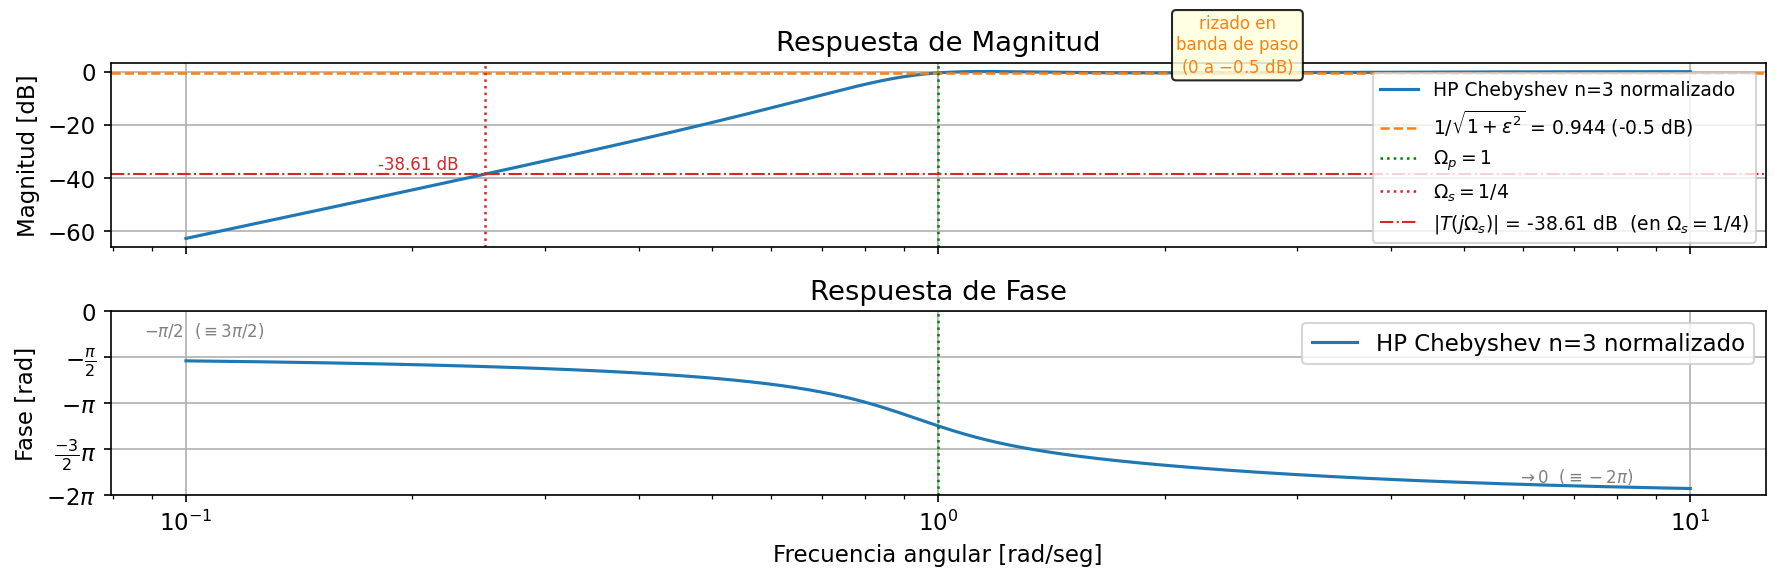

#### 2.2 — Bode HP desnormalizado (fp=40 kHz) con plantilla

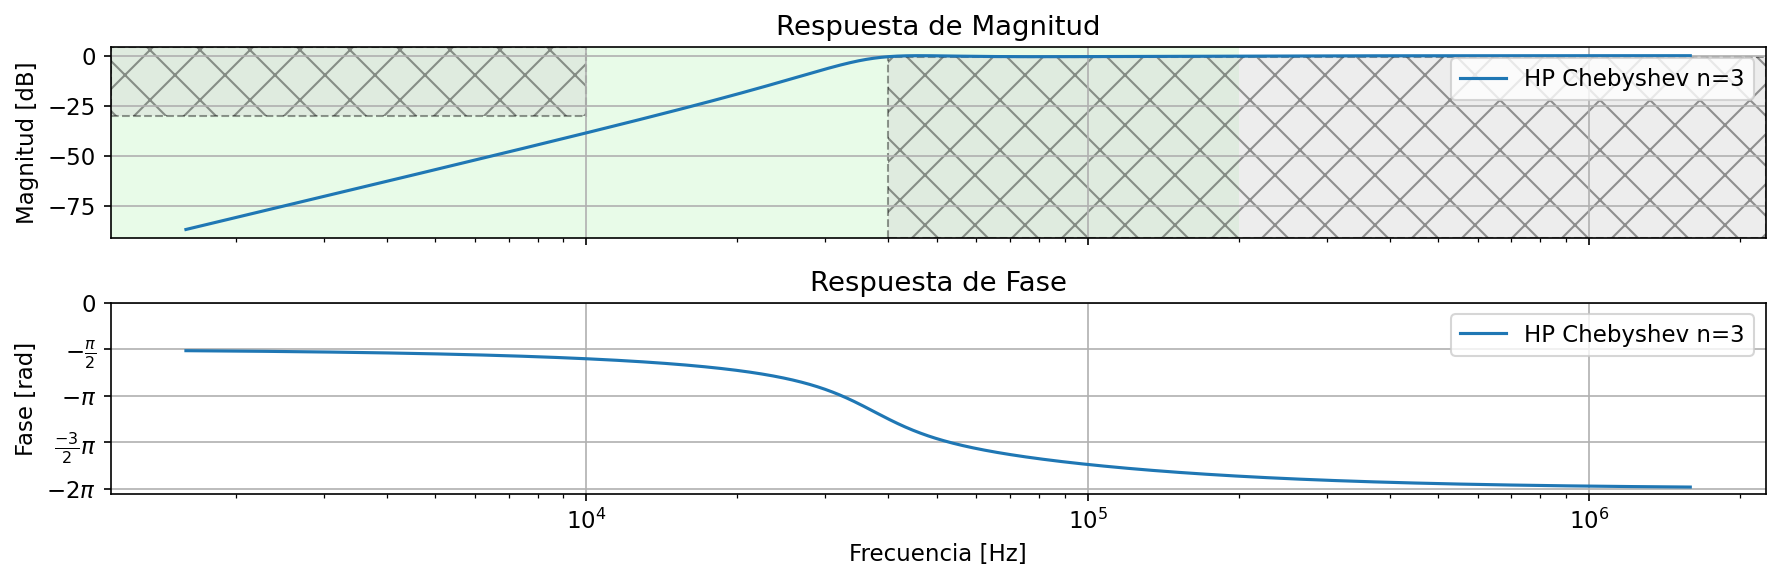

#### 2.3 — LP protótipo vs HP normalizado

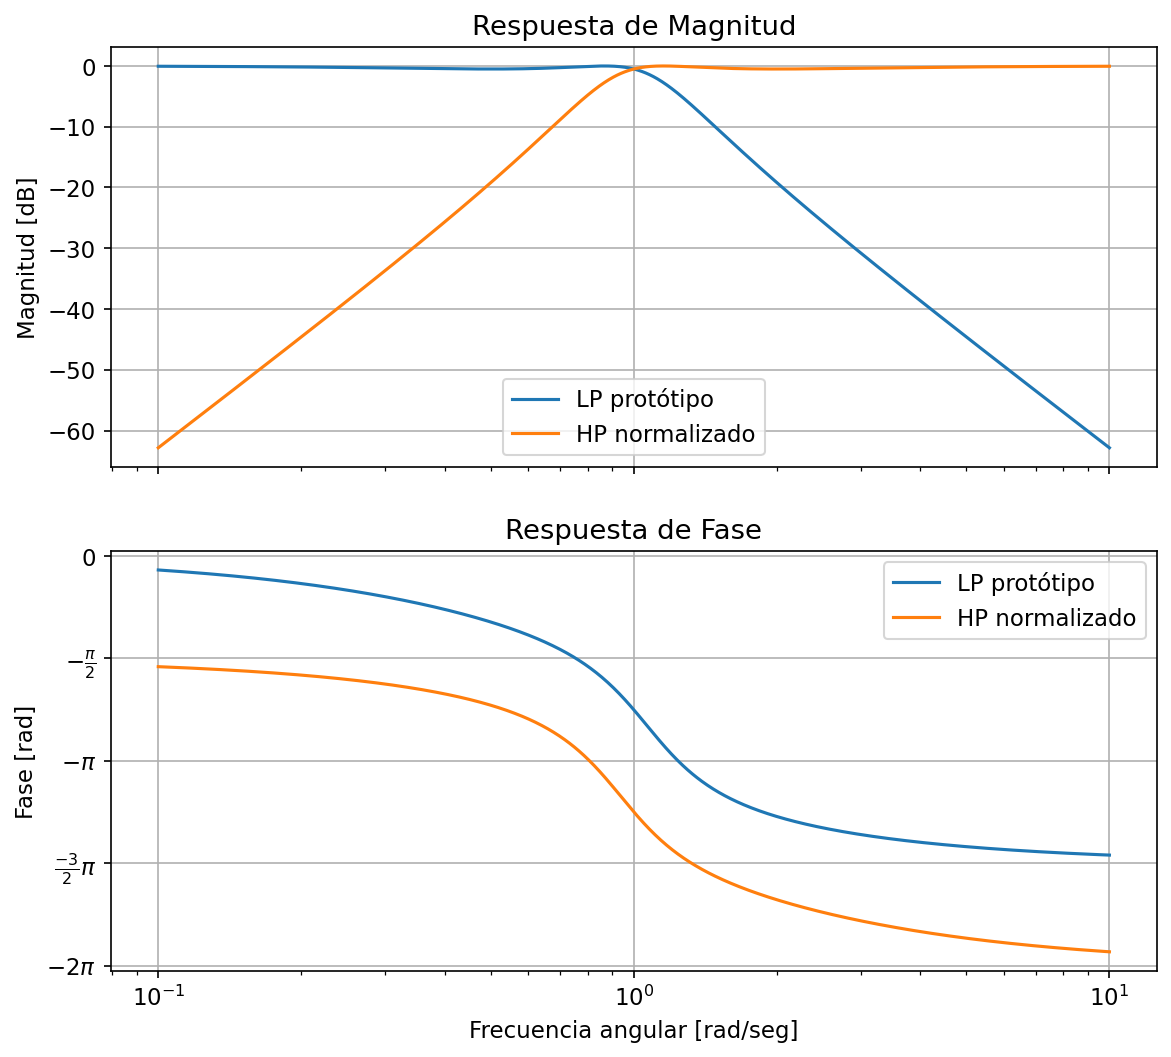

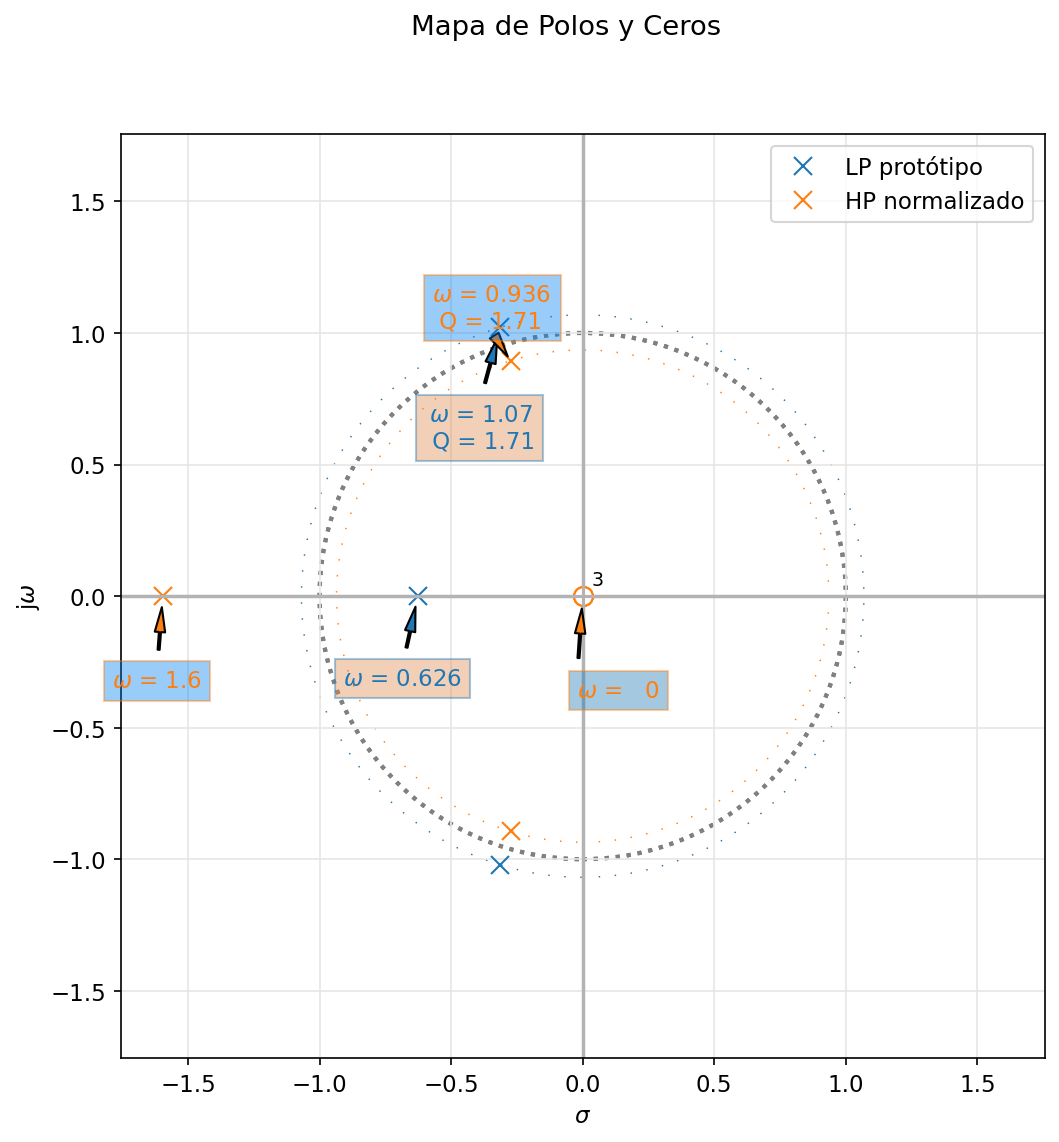

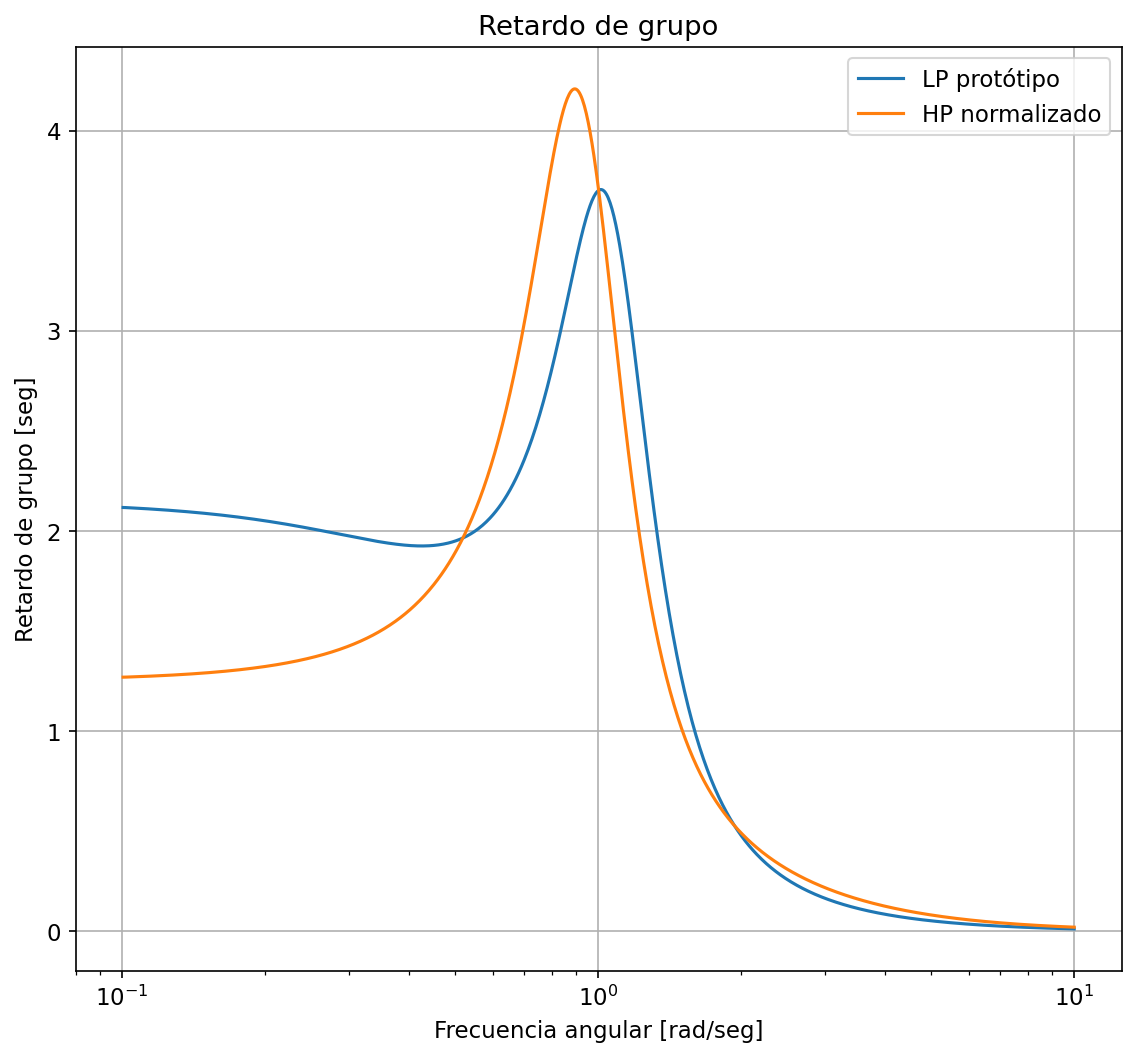

#### 2.4 — pzmap LP protótipo (ampliado)

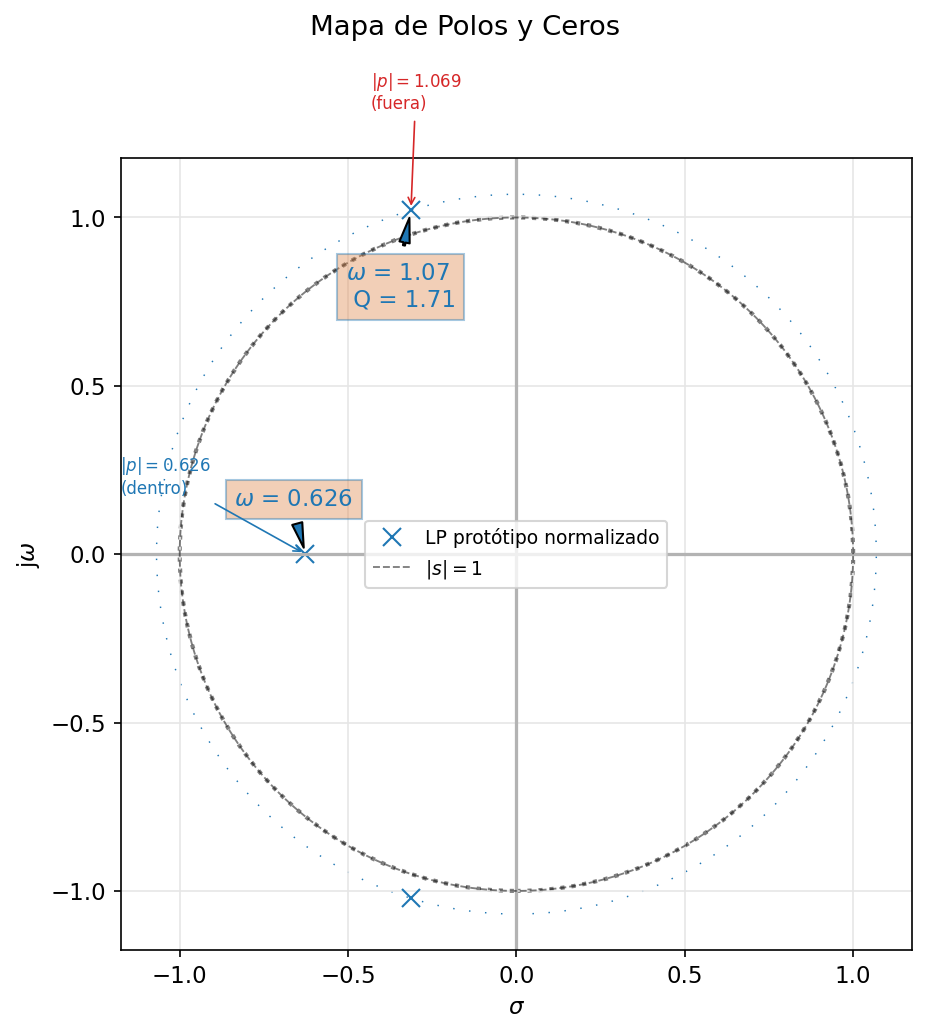

#### 2.4 — pzmap HP normalizado (ampliado)

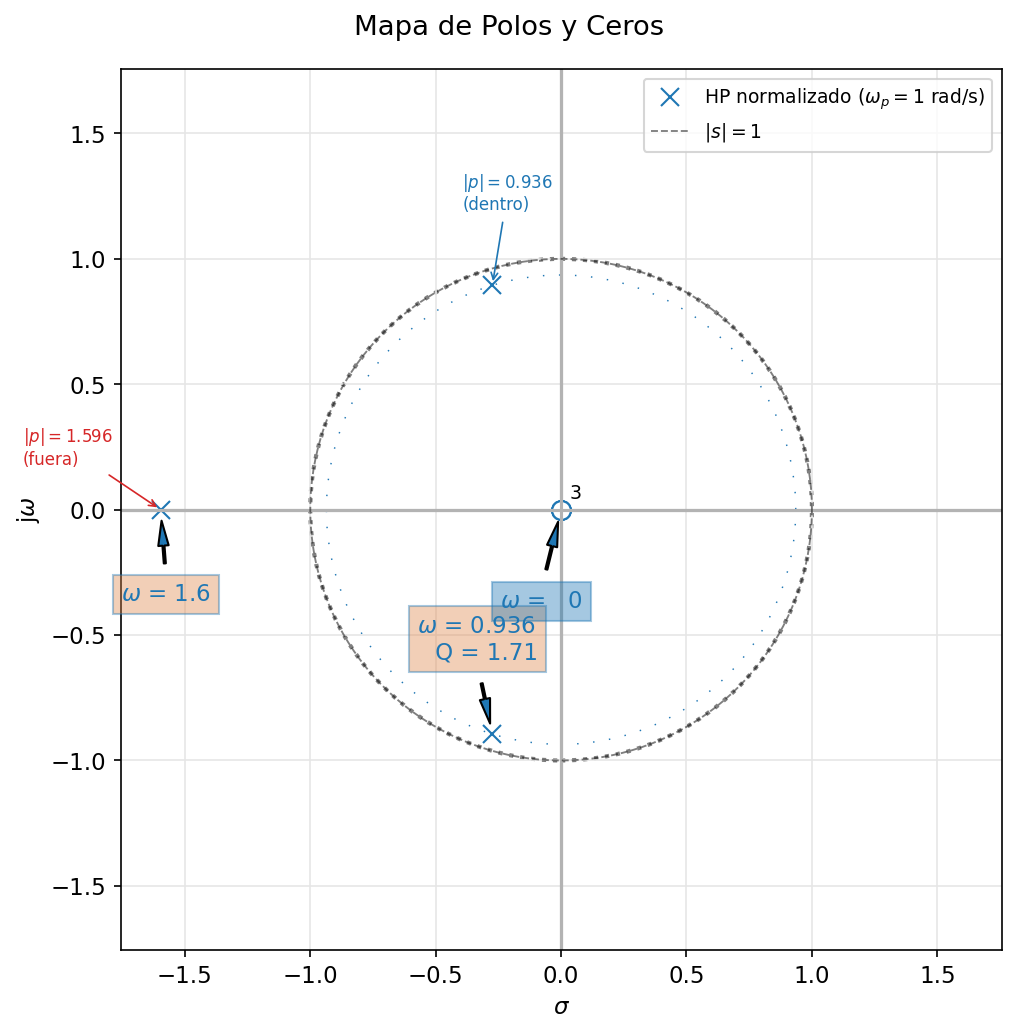

#### Extra — Retardo de grupo HP Chebyshev desnormalizado

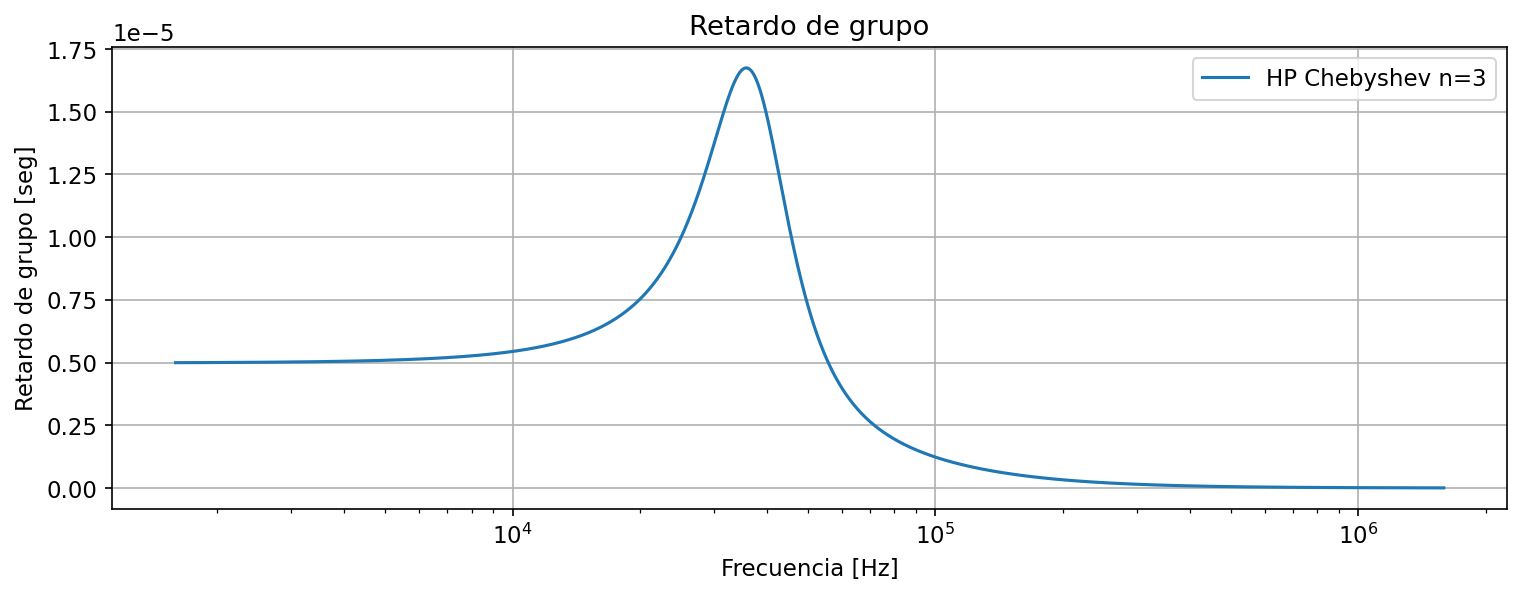

In [29]:
# Variables de p1_code: n, alpha_max_dB, alpha_min_dB, fp, fs, wp, ws
#                         b_lp, a_lp, b_hp_n, a_hp_n, b_hp, a_hp

H_lp   = sig.TransferFunction(b_lp,   a_lp)
H_hp_n = sig.TransferFunction(b_hp_n, a_hp_n)
H_hp   = sig.TransferFunction(b_hp,   a_hp)
theta  = np.linspace(0, 2*np.pi, 300)

T_at_wp_lin = 1 / np.sqrt(1 + eps2)    # 0.944
T_at_wp_dB  = 20 * np.log10(T_at_wp_lin)  # -0.5 dB

# ── 2.1 Bode normalizado anotado ──────────────────────────────────────────────
print_subtitle('2.1 — Bode HP normalizado (cualitativo, con anotaciones)')

fig_id, axes_hdl = bodePlot(H_hp_n, fig_id='none',
                             filter_description=f'HP Chebyshev n={n} normalizado',
                             worN=3000, xaxis='omega', unwrap_phase=True)
ax_mag = axes_hdl[0]
ax_ph  = axes_hdl[1]

# — Módulo: rizado, Ωp, Ωs —
ax_mag.axhline(T_at_wp_dB, color='C1', ls='--', lw=1.2,
               label=f'$1/\\sqrt{{1+\\varepsilon^2}}$ = {T_at_wp_lin:.3f} ({T_at_wp_dB:.1f} dB)')
ax_mag.axvline(1.0,  color='green', ls=':', lw=1.2, label='$\Omega_p = 1$')
ax_mag.axvline(0.25, color='C3',    ls=':', lw=1.2, label='$\Omega_s = 1/4$')
ax_mag.annotate('rizado en\nbanda de paso\n($0$ a $-0.5$ dB)',
                xy=(2.5, -0.25), fontsize=8, color='C1', ha='center',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='lightyellow', alpha=0.85))
ax_mag.legend(fontsize=9)

# — Línea horizontal en |T(jΩs)| con Ωs = 1/4 —
_, H_ws_n = sig.freqs(b_hp_n, a_hp_n, worN=[0.25])
mag_ws_dB = 20 * np.log10(abs(H_ws_n[0]))
ax_mag.axhline(mag_ws_dB, color='C3', ls='-.', lw=1.0,
               label=f'$|T(j\Omega_s)|$ = {mag_ws_dB:.2f} dB  (en $\Omega_s=1/4$)')
ax_mag.annotate(f'{mag_ws_dB:.2f} dB',
                xy=(ax_mag.get_xlim()[0]*1.5, mag_ws_dB),
                xytext=(0.18, mag_ws_dB + 2),
                fontsize=8, color='C3')
ax_mag.legend(fontsize=9)

# — Fase: valor en Ωp, inicio y fin —
w_arr = np.logspace(-2, 2, 6000)
_, H_arr = sig.freqs(b_hp_n, a_hp_n, worN=w_arr)
ph_unwr  = np.unwrap(np.angle(H_arr)) * 180 / np.pi
ph_at_wp = float(np.interp(1.0, w_arr, ph_unwr))

ax_ph.axvline(1.0, color='green', ls=':', lw=1.2)
ax_ph.annotate(
    f'$\\angle T(j\\Omega_p)$\n$= {ph_at_wp:.0f}°$\n$\\equiv 3\\pi/4$ (conv. manuscrito)',
    xy=(1.0, ph_at_wp),
    xytext=(3.5, ph_at_wp - 40),
    fontsize=8,
    arrowprops=dict(arrowstyle='->', lw=0.9))
# Inicio y fin — coordenadas relativas al axes para no estirar el eje
ax_ph.text(0.02, 0.95, '$-\pi/2$  $(\equiv 3\pi/2)$',
           transform=ax_ph.transAxes, fontsize=8, color='gray',
           va='top', ha='left')
ax_ph.text(0.92, 0.05, '$\\rightarrow 0$  $(\equiv -2\pi)$',
           transform=ax_ph.transAxes, fontsize=8, color='gray',
           va='bottom', ha='right')

plt.tight_layout()
plt.show()

# ── 2.2 Bode HP desnormalizado + plantilla ────────────────────────────────────
print_subtitle(f'2.2 — Bode HP desnormalizado (fp={fp/1e3:.0f} kHz) con plantilla')

fig_id, axes_hdl = bodePlot(H_hp, fig_id='none',
                             filter_description=f'HP Chebyshev n={n}',
                             worN=2000, xaxis='freq')
plt.sca(axes_hdl[0])
plot_plantilla(filter_type='highpass',
               fpass=fp, fstop=fs,
               ripple=alpha_max_dB, attenuation=alpha_min_dB,
               fs=10*fp)
plt.tight_layout()
plt.show()

# ── 2.3 LP vs HP normalizado (Bode + pzmap + retardo) ─────────────────────────
print_subtitle('2.3 — LP protótipo vs HP normalizado')

old_fs = plt.rcParams['figure.figsize']
plt.rcParams['figure.figsize'] = [9, 8]
analyze_sys([H_lp, H_hp_n],
            sys_name=['LP protótipo', 'HP normalizado'],
            xaxis='omega', annotations=True, same_figs=False)
plt.rcParams['figure.figsize'] = old_fs
plt.show()

# ── 2.4 pzmap ampliado con círculo unidad ─────────────────────────────────────
def _pzmap_ampliado(H, poles, titulo):
    old_fs = plt.rcParams['figure.figsize']
    plt.rcParams['figure.figsize'] = [7, 7]
    fig_id, ax = pzmap(H, annotations=True, filter_description=titulo)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.9, alpha=0.5, label='$|s|=1$')
    for p in [q for q in poles if q.imag >= -1e-10]:
        inside = abs(p) < 1 - 1e-6
        label  = f'$|p|={abs(p):.3f}$\n({"dentro" if inside else "fuera"})'
        color  = 'C0' if inside else 'C3'
        offset = (-0.55, +0.18) if p.imag < 0.1 else (-0.12, +0.30)
        ax.annotate(label, xy=(p.real, p.imag),
                    xytext=(p.real+offset[0], p.imag+offset[1]),
                    fontsize=8, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.8))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    plt.rcParams['figure.figsize'] = old_fs

print_subtitle('2.4 — pzmap LP protótipo (ampliado)')
_pzmap_ampliado(H_lp,   np.roots(a_lp),   'LP protótipo normalizado')

print_subtitle('2.4 — pzmap HP normalizado (ampliado)')
_pzmap_ampliado(H_hp_n, np.roots(a_hp_n), 'HP normalizado ($\omega_p = 1$ rad/s)')

# ── Extra: Retardo de grupo HP desnormalizado ─────────────────────────────────
print_subtitle('Extra — Retardo de grupo HP Chebyshev desnormalizado')

GroupDelay(H_hp, fig_id='none',
           filter_description=f'HP Chebyshev n={n}',
           worN=2000, xaxis='freq')
plt.show()


---

### 2.5 Retardo de grupo — expresión analítica

#### Resolución manuscrita

Originales: `gd_hoja_1.jpg` a `gd_hoja_3.jpg` en [img/](./img/)

<img src="./img/gd_hoja_1.jpg" width="450" />
<img src="./img/gd_hoja_2.jpg" width="450" />
<img src="./img/gd_hoja_3.jpg" width="450" />

---

#### Transcripción


El **retardo de grupo** cuantifica el retraso de la envolvente de una señal de banda angosta:

$$\boxed{\tau_g(\omega) = -\frac{d\,\phi(j\omega)}{d\omega}}$$

Como la cascada usa buffers ideales, el retardo total es la suma de los individuales:

$$\tau_g(\omega) = \tau_1(\omega) + \tau_2(\omega)$$

#### Sección de 1er orden HP: $T_1(s) = \dfrac{s}{s+\sigma_1}$

La fase es:

$$\phi_1(j\omega) = \underbrace{\frac{\pi}{2}}_{\text{aportado por el cero}} - \arctan\!\left(\frac{\omega}{\sigma_1}\right)$$

Derivando respecto a $\omega$:

$$\boxed{\tau_1(\omega) = \frac{\sigma_1}{\sigma_1^2 + \omega^2}}$$

#### Sección de 2do orden HP: $T_2(s) = \dfrac{s^2}{s^2 + \frac{\omega_0}{Q}s + \omega_0^2}$

El numerador $(j\omega)^2 = -\omega^2$ aporta una fase constante $\pi$, por lo que:

$$\phi_2(j\omega) = \pi - \phi_{D_2}(j\omega), \quad D_2(j\omega) = \underbrace{(\omega_0^2-\omega^2)}_{\text{Re}} + j\underbrace{\frac{\omega_0\,\omega}{Q}}_{\text{Im}}$$

donde la fase de $D_2$ es explícitamente:

$$\phi_{D_2}(j\omega) = \arctan\!\left(\frac{\omega\,\omega_0/Q}{\omega_0^2-\omega^2}\right)$$

por lo tanto:

$$\phi_2(j\omega) = \pi - \arctan\!\left(\frac{\omega\,\omega_0/Q}{\omega_0^2-\omega^2}\right)$$

Al derivar, la constante $\pi$ desaparece y se obtiene **la misma expresión que para un biquad LPF** con iguales $\omega_0$ y $Q$:

Sea $u = \dfrac{\omega_0\omega/Q}{\omega_0^2-\omega^2}$; con la regla de la cadena sobre $\arctan(u)$:

$$\frac{du}{d\omega} = \frac{\omega_0}{Q}\cdot\frac{\omega_0^2+\omega^2}{(\omega_0^2-\omega^2)^2}, \qquad 1+u^2 = \frac{(\omega_0^2-\omega^2)^2+(\omega_0\omega/Q)^2}{(\omega_0^2-\omega^2)^2}$$

Sustituyendo:

$$\boxed{\tau_2(\omega) = \frac{(\omega_0/Q)\,(\omega_0^2+\omega^2)}{(\omega_0^2-\omega^2)^2 + (\omega_0\,\omega/Q)^2}}$$

> **Observación:** la fórmula del retardo de grupo de la sección HP es idéntica a la de la sección LP equivalente: la diferencia de $\pi$ en la fase no afecta a su derivada. Sin embargo, los **valores numéricos** del retardo serán distintos entre el LP y el HP, ya que los polos (y por lo tanto $\omega_0$ y $Q$) se ubican en posiciones diferentes en el plano $s$ como consecuencia de la transformación $s \leftarrow 1/s$. La misma expresión analítica con distintos $\omega_0$ y $Q$ produce curvas $\tau_g(\omega)$ diferentes.

#### Casos notables

**En $\omega \to 0$** (denominador $\to \omega_0^4$, numerador $\to \omega_0^3/Q$):

$$\tau_1(0) = \frac{1}{\sigma_1}, \qquad \tau_2(0) = \frac{1}{\omega_0\,Q} \qquad \Rightarrow \qquad \tau_g(0) = \frac{1}{\sigma_1} + \frac{1}{\omega_0\,Q}$$

**En $\omega = \omega_0$** (denominador $\to (\omega_0^2/Q)^2$, numerador $\to 2\omega_0^3/Q$):

$$\tau_2(\omega_0) = \frac{2Q}{\omega_0} \qquad \Rightarrow \qquad \tau_g(\omega_0) = \frac{\sigma_1}{\sigma_1^2+\omega_0^2} + \frac{2Q}{\omega_0}$$

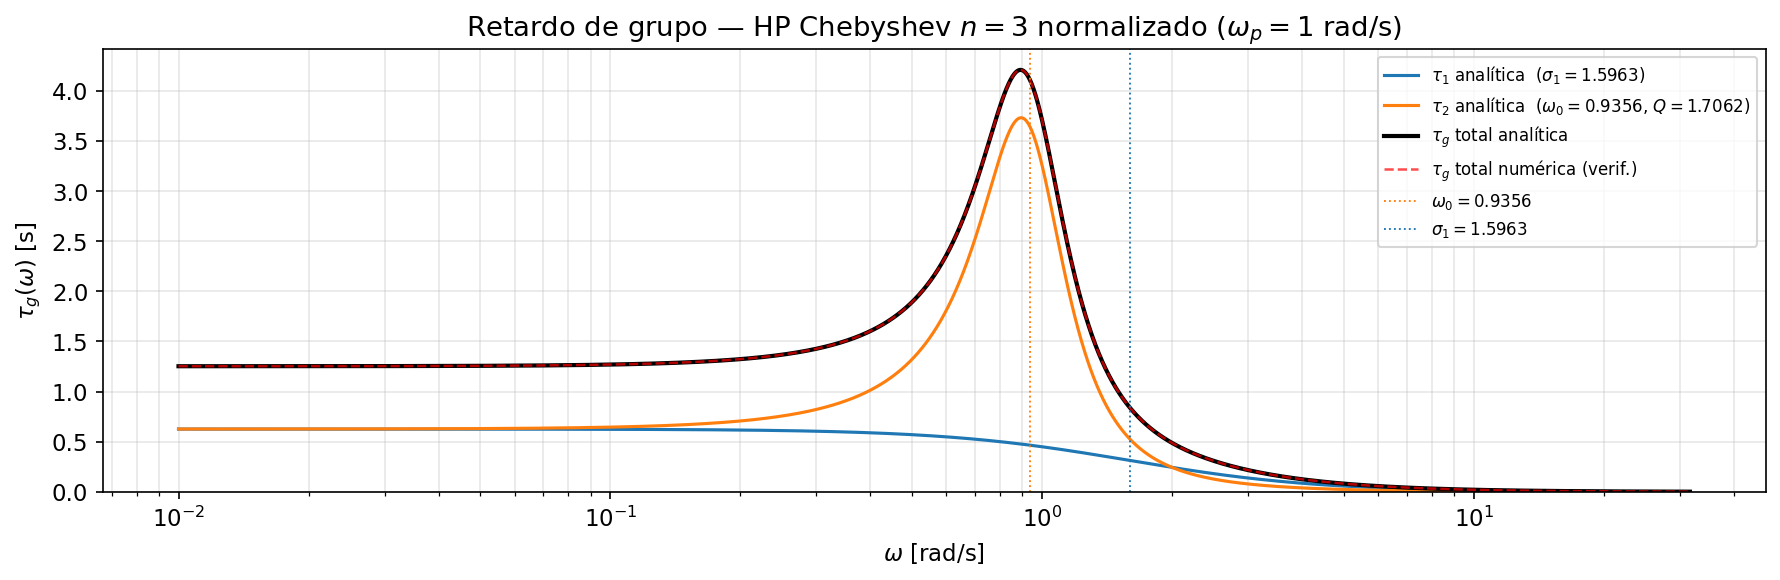

#### Verificación de los valores analíticos

  τ_g(0):
    fórmula:  1/σ₁ + 1/(ω₀·Q) = 0.6265 + 0.6265 = 1.2529 s
    numérico: 1.2531 s  ✓

  τ₂(ω₀):
    fórmula:  2Q/ω₀ = 3.6473 s
    numérico: 3.6480 s  ✓


In [30]:
# ── Retardo de grupo HP Chebyshev n=3 — verificación analítica vs numérica ────
# Variables de p1_code: p_hp_n, b_hp_n, a_hp_n

# Extraer parámetros directamente de los polos del HP normalizado
_p_real = [p for p in p_hp_n if abs(p.imag) < 1e-6][0]
_p_cx   = [p for p in p_hp_n if p.imag > 0][0]
sigma1  = abs(_p_real.real)              # polo real: -sigma1
w0_2    = abs(_p_cx)                     # ω₀ del par complejo
Q_2     = abs(_p_cx) / (-2*_p_cx.real)  # Q del par complejo

w_gd = np.logspace(-2, 1.5, 4000)

# ── Fórmulas analíticas ───────────────────────────────────────────────────────
tau1_an = sigma1 / (sigma1**2 + w_gd**2)
tau2_an = (w0_2/Q_2)*(w0_2**2 + w_gd**2) / ((w0_2**2 - w_gd**2)**2 + (w0_2*w_gd/Q_2)**2)
tau_tot_an = tau1_an + tau2_an

# ── Verificación numérica (diferenciación de la fase) ────────────────────────
def tau_g_num(b, a, w):
    _, H = sig.freqs(b, a, worN=w)
    return -np.gradient(np.unwrap(np.angle(H)), w)

b_sos2 = np.array([1, 0, 0])
a_sos2 = np.array([1, w0_2/Q_2, w0_2**2])
b_sos1 = np.array([1, 0])
a_sos1 = np.array([1, sigma1])

tau1_num = tau_g_num(b_sos1, a_sos1, w_gd)
tau2_num = tau_g_num(b_sos2, a_sos2, w_gd)
tau_tot_num = tau_g_num(b_hp_n, a_hp_n, w_gd)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ax.semilogx(w_gd, tau1_an,   'C0-',  lw=1.5, label=f'$\\tau_1$ analítica  ($\\sigma_1={sigma1:.4f}$)')
ax.semilogx(w_gd, tau2_an,   'C1-',  lw=1.5, label=f'$\\tau_2$ analítica  ($\\omega_0={w0_2:.4f}$, $Q={Q_2:.4f}$)')
ax.semilogx(w_gd, tau_tot_an,'k-',   lw=2.0, label='$\\tau_g$ total analítica')
ax.semilogx(w_gd, tau_tot_num,'r--', lw=1.2, label='$\\tau_g$ total numérica (verif.)', alpha=0.7)
ax.axvline(w0_2,   color='C1', ls=':', lw=0.9, label=f'$\\omega_0={w0_2:.4f}$')
ax.axvline(sigma1, color='C0', ls=':', lw=0.9, label=f'$\\sigma_1={sigma1:.4f}$')
ax.set_xlabel('$\\omega$ [rad/s]'); ax.set_ylabel('$\\tau_g(\\omega)$ [s]')
ax.set_title('Retardo de grupo — HP Chebyshev $n=3$ normalizado ($\\omega_p=1$ rad/s)')
ax.set_ylim(0, None); ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Verificación de los casos analíticos ─────────────────────────────────────
dc_i  = np.argmin(np.abs(w_gd - 0.01))
w0_i  = np.argmin(np.abs(w_gd - w0_2))

print_subtitle('Verificación de los valores analíticos')
print(f'  τ_g(0):')
print(f'    fórmula:  1/σ₁ + 1/(ω₀·Q) = {1/sigma1:.4f} + {1/(w0_2*Q_2):.4f} = {1/sigma1 + 1/(w0_2*Q_2):.4f} s')
print(f'    numérico: {tau_tot_num[dc_i]:.4f} s  {"✓" if abs(tau_tot_num[dc_i]-(1/sigma1+1/(w0_2*Q_2)))<0.05 else "✗"}')
print()
print(f'  τ₂(ω₀):')
print(f'    fórmula:  2Q/ω₀ = {2*Q_2/w0_2:.4f} s')
print(f'    numérico: {tau2_num[w0_i]:.4f} s  {"✓" if abs(tau2_num[w0_i]-2*Q_2/w0_2)<0.05 else "✗"}')


<a id="p3"></a>

***

## Punto 3 — Red normalizada con estructuras pasivas y buffers activos

### Resolución manuscrita

Originales: `p3_hoja_1.jpg` y `p3_hoja_2.jpg` en [img/](./img/)

<img src="./img/p3_hoja_1.jpg" width="450" />
<img src="./img/p3_hoja_2.jpg" width="450" />

---

### Transcripción

#### 3.1 Topología elegida

La TF normalizada del filtro HP ($\omega_p = 1$ rad/s) se descompone en dos secciones en cascada, separadas por un **buffer** (seguidor de tensión con opamp) para evitar el efecto de carga entre etapas:

$$T_{\text{HP,norm}}(s) = \underbrace{\frac{s^2}{s^2 + 0{,}5483\,s + 0{,}8753}}_{T_1(s)\;(\text{2do orden})} \cdot \underbrace{\frac{s}{s + 1{,}5963}}_{T_2(s)\;(\text{1er orden})}$$

#### 3.2 SOS de 2do orden — par de polos complejos conjugados y doble cero en el origen

**Circuito:** $R$ en serie, $C$ en serie, $L$ en paralelo a masa.

$$\frac{V_o}{V_i} = \frac{Z_L}{Z_R + Z_C + Z_L} = \frac{sL}{R + \dfrac{1}{sC} + sL}$$

Multiplicando numerador y denominador por $sC$:

$$T_1(s) = \frac{s^2 LC}{s^2 LC + sCR + 1} = \frac{s^2}{s^2 + s\,\dfrac{R}{L} + \dfrac{1}{LC}}$$

Igualando con la SOS del filtro normalizado $\left(s^2 + 0{,}5483\,s + 0{,}8753\right)$:

$$\frac{R}{L} = 0{,}5483 \xrightarrow{R=1\,\Omega} \boxed{L = \frac{1}{0{,}5483} = 1{,}8237\,\text{H}}$$

$$\frac{1}{LC} = 0{,}8753 \implies C = \frac{1}{0{,}8753 \times 1{,}8237} = \frac{1}{1{,}5963} = \boxed{0{,}6264\,\text{F}}$$

Parámetros de la SOS:

$$\omega_0 = \sqrt{\frac{1}{LC}} = \sqrt{0{,}8753} = 0{,}9356\,\text{rad/s}, \qquad Q = \frac{\omega_0\,L}{R} = 0{,}9356 \times 1{,}8237 = \boxed{1{,}706}$$

#### 3.3 SOS de 1er orden — polo real y cero en el origen

**Circuito:** $R$ en serie, $L$ en paralelo a masa.

$$T_2(s) = \frac{Z_L}{Z_R + Z_L} = \frac{sL}{R + sL} = \frac{s}{s + \dfrac{R}{L}}$$

Igualando con $(s + 1{,}5963)$:

$$\frac{R}{L} = 1{,}5963 \xrightarrow{R=1\,\Omega} \boxed{L = \frac{1}{1{,}5963} = 0{,}6264\,\text{H}}$$

#### 3.4 Resumen de componentes normalizados

| Sección | $R$ | $C$ | $L$ |
|:---|:---:|:---:|:---:|
| SOS 2do orden | $1\,\Omega$ | $0{,}6264\,\text{F}$ | $1{,}8237\,\text{H}$ |
| SOS 1er orden | $1\,\Omega$ | — | $0{,}6264\,\text{H}$ |

---

### Verificación en LTSpice

#### Circuito simulado

<div align="center"><img src="./img/p3_lt_11.jpg" width="950" /></div>

> **Figura:** circuito en LTSpice con los componentes normalizados. Primera sección HP de 2do orden: $R_1=1\,\Omega$, $C_1=0{,}62644\,\text{F}$, $L_1=1{,}8237\,\text{H}$ (shunt). Buffer opamp (`.lib opamp.sub`). Segunda sección HP de 1er orden: $R_2=1\,\Omega$, $L_2=0{,}62644\,\text{H}$ (shunt). Barrido: `.ac dec 10000 0.001 1000`.

---

#### Respuesta en dB — cursor en $\omega_p$ normalizado

<div align="center"><img src="./img/p3_lt_01.jpg" width="950" /></div>

> **Figura:** módulo en dB y fase de la cascada completa. Cursor en $f = 159{,}4\,\text{mHz}$ $\left(= \omega_p / 2\pi = 1\,\text{rad/s} / 2\pi\right)$:
> - $|T(j\omega_p)| = -501{,}4\,\text{mdB} \approx -0{,}5\,\text{dB}$ ✓ — borde de banda de paso Chebyshev
> - $\angle T(j\omega_p) = -225{,}3° \equiv 3\pi/4 = 135°$ ✓

---

#### Respuesta en dB — zona de rechazo

<div align="center"><img src="./img/p3_lt_02.jpg" width="950" /></div>

> **Figura:** dos cursores en zona de rechazo.
> - Cursor 1: $f = 100\,\text{mHz}$, $|T| = -12{,}24\,\text{dB}$
> - Cursor 2: $f = 10\,\text{mHz}$, $|T| = -74{,}99\,\text{dB}$
> - En 1 década (de 10 mHz a 100 mHz): $\Delta = 62{,}75\,\text{dB}$ — pendiente aproximada de $60\,\text{dB/dec}$, propia de un HPF de orden 3. El valor no es exactamente $60\,\text{dB/dec}$ porque aún estamos cerca de la banda de paso, donde la respuesta todavía no alcanzó la zona asintótica de pendiente constante.

---

#### Respuesta en dB — zona de paso

<div align="center"><img src="./img/p3_lt_03.jpg" width="950" /></div>

> **Figura:** dos cursores en banda de paso, muy por encima de $\omega_p$.
> - A $1\,\text{Hz}$ ($\approx 6{,}28\,\text{rad/s}$): $|T| = -112\,\mu\text{dB} \approx 0\,\text{dB}$ ✓
> - A $1\,\text{kHz}$: $|T| = -87\,\mu\text{dB} \approx 0\,\text{dB}$ ✓
> - El filtro converge a ganancia unitaria ($0\,\text{dB}$) bien adentro de la banda de paso. La fase tiende a $0°$ ($\equiv -360°$). ✓

---

#### Respuesta en escala lineal — cursor en $\omega_p$

<div align="center"><img src="./img/p3_lt_04.jpg" width="950" /></div>

> **Figura:** módulo en escala lineal. Cursor en $f = 159{,}0\,\text{mHz}$:
> - $|T(j\omega_p)| = 941{,}6\,\text{m} = 0{,}9416 \approx \dfrac{1}{\sqrt{1+\varepsilon^2}} = 0{,}9441$ ✓
> - $\angle T(j\omega_p) = -224{,}75° \equiv 135°$ ✓

---

#### Escala lineal — SOS 2do orden (azul) vs SOS 1er orden (verde)

<div align="center"><img src="./img/p3_lt_05.jpg" width="950" /></div>

> **Figura:** respuesta en veces. Azul: SOS 2do orden $V(\text{voSOS})/V(v_i)$; verde: SOS 1er orden $V(v_o)/V(v_{i2})$.
> - La SOS 2do orden presenta un **pico de resonancia** de $\approx 1{,}78$ cerca de $\omega_0 = 0{,}9356\,\text{rad/s}$ ($f \approx 149\,\text{mHz}$), producto del $Q = 1{,}706$.
> - La SOS 1er orden tiene una transición de 1er orden suave sin pico, llegando a ganancia unitaria en alta frecuencia.

---

#### Escala dB — SOS 2do orden (azul) vs SOS 1er orden (verde)

<div align="center"><img src="./img/p3_lt_06.jpg" width="950" /></div>
<div align="center"><img src="./img/p3_lt_07.jpg" width="950" /></div>

> **Figura:** mismo gráfico en dB. La SOS 2do orden (azul) presenta un pico de $\approx +5\,\text{dB}$ en $\omega_0$, efecto del $Q \approx 1{,}7$.  
> La SOS 1er orden (verde) tiene pendiente $20\,\text{dB/dec}$ en zona de rechazo y no presenta pico. Al cascadear ambas secciones se obtiene la respuesta Chebyshev completa con rizado en banda de paso ($0$ a $-0{,}5\,\text{dB}$).

---

#### Pendiente de la SOS 2do orden en zona de rechazo

<div align="center"><img src="./img/p3_lt_08.jpg" width="950" /></div>

> **Figura:** cursores sobre $V(\text{voSOS})/V(v_i)$ en zona de rechazo:
> - De $1\,\text{mHz}$ ($-86{,}88\,\text{dB}$) a $10\,\text{mHz}$ ($-46{,}82\,\text{dB}$): $\Delta = 40{,}06\,\text{dB/dec}$ ✓
> - Pendiente $40\,\text{dB/dec}$ confirma un HPF de **2do orden** en la zona asintótica.

---

#### Pendiente de la SOS 1er orden en zona de rechazo

<div align="center"><img src="./img/p3_lt_09.jpg" width="950" /></div>

> **Figura:** cursores sobre la SOS 1er orden $V(v_o)/V(v_{i2})$ (verde):
> - De $1\,\text{mHz}$ ($-47{,}84\,\text{dB}$) a $10\,\text{mHz}$ ($-28{,}11\,\text{dB}$): $\Delta \approx 19{,}7\,\text{dB/dec}$.
> - Pendiente aproximada de $\mathbf{20\,\text{dB/dec}}$, confirma un HPF de **1er orden** en la zona asintótica. ✓

---

#### Fase — SOS 2do orden (azul) vs SOS 1er orden (verde)

<div align="center"><img src="./img/p3_lt_10.jpg" width="950" /></div>

> **Figura:** fase de ambas secciones. La SOS 2do orden (azul) parte de $\approx 180°$ en baja frecuencia (2 ceros en el origen) y converge a $0°$. La SOS 1er orden (verde) parte de $\approx 90°$ (1 cero en el origen) y también converge a $0°$. Ambas son consistentes con sus respectivos órdenes.

---

### Conclusión: analítico vs simulación (Punto 3)

| Magnitud | Valor analítico | LTSpice (cursor) | ¿Coincide? |
|:---|:---:|:---:|:---:|
| $\|T(j\omega_p)\|$ en $f = \omega_p/2\pi = 159\,\text{mHz}$ | $-0{,}5\,\text{dB}$ | $-501{,}4\,\text{mdB}$ | ✓ |
| Fase en $\omega_p$ | $-225°$ ($\equiv 3\pi/2$) | $-225{,}3°$ | ✓ |
| $\|T(j\omega_p)\|$ en escala lineal | $0{,}9441$ | $0{,}9416$ | ✓ |
| Pendiente en zona de rechazo | $\approx 60\,\text{dB/dec}$ | $62{,}75\,\text{dB/dec}$ | ≈✓ |
| Atenuación en $\Omega_s = 1/4$ | $38{,}61\,\text{dB}$ (cálculo del orden) | $38{,}61\,\text{dB}$ | ✓ |

> Los resultados de la simulación coinciden con los valores analíticos en todos los puntos de interés. La pequeña diferencia en la pendiente ($62{,}75$ vs $60\,\text{dB/dec}$) se debe a que los cursores se ubicaron cerca de la banda de paso, donde aún no se alcanzó la zona asintótica de $60\,\text{dB/dec}$ del HPF de orden 3.

<a id="p4"></a>

***

## Punto 4 — Reemplazo de inductores por GIC de Antoniou

### Resolución manuscrita

Originales: `p4_hoja_1.jpg` a `p4_hoja_3.jpg` en [img/](./img/)

<img src="./img/p4_hoja_1.jpg" width="450" />
<img src="./img/p4_hoja_2.jpg" width="450" />
<img src="./img/p4_hoja_3.jpg" width="450" />

---

### Transcripción

#### 4.1 GIC de Antoniou — derivación general

El **GIC (Conversor Generalizado de Impedancia)** de Antoniou es un circuito de dos amplificadores operacionales con cinco impedancias $Z_1 \ldots Z_5$ (o admitancias $Y_k = 1/Z_k$). Utilizando la hipótesis de **A.O. ideal** ($V_+ = V_-$, $I_{entrada} = 0$):

$$V_i = V_B = V_D$$

Aplicando el Método de Nodos y Admitancias en los nodos $A$, $B$ y $D$:

$$V_i Y_1 - V_A Y_1 - I_1 = 0 \tag{1}$$

$$V_B(Y_2+Y_3) - V_A Y_2 - V_C Y_3 = 0 \tag{2}$$

$$V_D(Y_4+Y_5) - V_C Y_4 = 0 \implies V_C = \frac{Y_4+Y_5}{Y_4}\,V_i \tag{3}$$

Sustituyendo $(3)$ en $(2)$ con $V_B = V_i$:

$$V_i(Y_2+Y_3) - V_A Y_2 - \frac{Y_4+Y_5}{Y_4}\,V_i\,Y_3 = 0$$

$$V_A = \frac{V_i}{Y_2}\left(Y_2+Y_3 - Y_3\,\frac{Y_4+Y_5}{Y_4}\right) = V_i\,\frac{(Y_2+Y_3)Y_4 - Y_3(Y_4+Y_5)}{Y_2\,Y_4} \tag{5}$$

Sustituyendo $(5)$ en $(1)$:

$$I_1 = V_i\,Y_1\left(1 - \frac{(Y_2+Y_3)Y_4 - Y_3(Y_4+Y_5)}{Y_2\,Y_4}\right)$$

$$I_1 = V_i\,Y_1\;\frac{Y_2 Y_4 - (Y_2+Y_3)Y_4 + Y_3(Y_4+Y_5)}{Y_2\,Y_4}$$

Desarrollando el numerador:

$$Y_2 Y_4 - Y_2 Y_4 - Y_3 Y_4 + Y_3 Y_4 + Y_3 Y_5 = Y_3 Y_5$$

Por lo tanto:

$$\boxed{Z_i = \frac{V_i}{I_i} = \frac{Y_2\,Y_4}{Y_1\,Y_3\,Y_5} = \frac{Z_1\,Z_3\,Z_5}{Z_2\,Z_4}}$$

#### 4.2 Configuración para simular inductor a tierra

Se elige $Z_2 = \dfrac{1}{sC'}$ (capacitor) y $Z_1 = Z_3 = Z_4 = Z_5 = R = 1\,\Omega$ (resistencias):

$$Z_i = \frac{1 \cdot 1 \cdot 1}{\dfrac{1}{sC'} \cdot 1} = sC' = sL_{\text{eq}}$$

Con $R = 1\,\Omega$: $\quad L_{\text{eq}} = C'$ (en unidades normalizadas). El capacitor toma el valor del inductor a reemplazar.

#### 4.3 Valores aplicados al filtro normalizado

Se reemplazan los dos inductores de la red del Punto 3:

| Inductor | Valor original | Capacitor GIC equivalente |
|:---|:---:|:---:|
| $L_1$ (SOS 2do orden) | $1{,}8237\,\text{H}$ | $C_1' = 1{,}8237\,\text{F}$ |
| $L_2$ (SOS 1er orden) | $0{,}6264\,\text{H}$ | $C_2' = 0{,}6264\,\text{F}$ |

Cada GIC usa **2 opamps**, **4 resistencias de $1\,\Omega$** y **1 capacitor** $C'$, eliminando completamente los inductores.

---

### Verificación en LTSpice

#### Circuito simulado con GICs

<div align="center"><img src="./img/p4_lt_05.jpg" width="950" /></div>

> **Figura:** circuito LTSpice con los inductores reemplazados por GICs de Antoniou.
> - **GIC para $L_1$** (SOS 2do orden): $R_3=R_4=R_5=R_7=1\,\Omega$, $C_2=1{,}8237\,\text{F}$, opamps U2+U3.
> - **GIC para $L_2$** (SOS 1er orden): $R_6=R_8=R_{10}=R_9=1\,\Omega$, $C_3=0{,}6264\,\text{F}$, opamps U4+U5.
> - Buffer U1 entre secciones. Barrido `.ac dec 10000 0.001 1000`.

---

#### Respuesta en dB — visión general

<div align="center"><img src="./img/p4_lt_01.jpg" width="950" /></div>

> **Figura:** módulo y fase de la cascada con GICs. La forma es idéntica a la del Punto 3 con inductores reales, confirmando que los GICs simulan correctamente los inductores.

---

#### Cursor en $\omega_p$ normalizado

<div align="center"><img src="./img/p4_lt_02.jpg" width="950" /></div>

> **Figura:** cursor en $f = 153{,}1\,\text{mHz}$ $(\approx \omega_p/2\pi)$:
> - $|T(j\omega_p)| = -501{,}8\,\text{mdB} \approx -0{,}5\,\text{dB}$ ✓ — borde de banda de paso Chebyshev
> - $\angle T(j\omega_p) = -224{,}9° \equiv 135° = 3\pi/4$ ✓
> - Resultado **idéntico** al obtenido con inductores reales en el Punto 3. ✓

---

#### Pendiente en zona de rechazo

<div align="center"><img src="./img/p4_lt_03.jpg" width="950" /></div>

> **Figura:** dos cursores en zona de rechazo:
> - Cursor 1: $1\,\text{mHz}$, $|T| = -135{,}01\,\text{dB}$
> - Cursor 2: $10\,\text{mHz}$, $|T| = -74{,}99\,\text{dB}$
> - $\Delta = 60{,}03\,\text{dB/dec}$ — pendiente asintótica de **60 dB/dec**, confirma HPF de orden 3. ✓

---

#### Respuesta en escala lineal

<div align="center"><img src="./img/p4_lt_04.jpg" width="950" /></div>

> **Figura:** módulo en veces y fase. El módulo converge a $1$ en alta frecuencia con rizado visible en la banda de paso ($1/\sqrt{1+\varepsilon^2} \approx 0{,}944$ en $\omega_p$). La fase recorre $270°$ de forma continua. Respuesta equivalente a la del Punto 3. ✓

---

### Conclusión: analítico vs simulación (Punto 4)

| Magnitud | Punto 3 (inductores reales) | Punto 4 (GIC) | ¿Coincide? |
|:---|:---:|:---:|:---:|
| $\|T(j\omega_p)\|$ | $-501{,}4\,\text{mdB}$ | $-501{,}8\,\text{mdB}$ | ✓ |
| Fase en $\omega_p$ | $-225{,}3°$ | $-224{,}9°$ | ✓ |
| Pendiente en rechazo | $62{,}75\,\text{dB/dec}$ | $60{,}025\,\text{dB/dec}$ | ✓ |

> El reemplazo de los inductores por GICs de Antoniou no altera la respuesta en frecuencia del filtro. Los valores simulados son prácticamente idénticos a los del Punto 3, confirmando que la impedancia $Z_i = Z_1 Z_3 Z_5 / (Z_2 Z_4) = sL_{eq}$ reproduce fielmente el comportamiento inductivo en todo el rango de frecuencias simulado.

<a id="p5"></a>

***

## Punto 5 — SOS pasiva → MFB pasa altos + análisis de sensibilidad

### Resolución manuscrita

Originales: `p5_hoja_1.jpg` a `p5_hoja_4.jpg` en [img/](./img/)

<img src="./img/p5_hoja_1.jpg" width="450" />
<img src="./img/p5_hoja_2.jpg" width="450" />
<img src="./img/p5_hoja_3.jpg" width="450" />
<img src="./img/p5_hoja_4.jpg" width="450" />

---

### Transcripción

#### 5.1 Análisis genérico de la topología MFB

La celda **MFB (Multiple Feedback)** tiene 5 admitancias $Y_1 \ldots Y_5$ y un amplificador operacional. Aplicando el Método de Nodos y Admitancias con A.O. ideal ($V_+ = 0$, $V_- = 0$):

**Nodo $V_x$:**
$$V_x(Y_1+Y_2+Y_3+Y_4) - V_i\,Y_1 - V_o\,Y_5 - 0\cdot Y_4 = 0 \tag{1}$$

**Nodo $V$ (entrada inversora, $V_- = 0$):**
$$V_x(Y_2+Y_3) - V_o\,Y_3 = 0 \implies V_x = \frac{V_o\,Y_3}{Y_2+Y_3}... $$

Simplificando mediante las relaciones del A.O. ideal:

$$V_x = \frac{-V_o\,Y_3}{Y_2} \tag{4}$$

Sustituyendo $(4)$ en $(1)$ y despejando:

$$\frac{V_o}{V_i} = \frac{-Y_2\,Y_3}{Y_5(Y_1+Y_2+Y_3+Y_4) + Y_3\,Y_4}$$

#### 5.2 Sustitución pasa altos

Se asignan: $Y_1 = sC_1$, $Y_2 = sC_3$, $Y_3 = sC_2$, $Y_4 = 1/R_1$, $Y_5 = 1/R_2$.

Numerador:
$$-Y_2\,Y_3 = -s^2 C_2 C_3$$

Denominador (desarrollado y dividido por $C_1 C_2$):
$$s^2 C_1 C_2 + s\,\frac{C_1+C_2+C_3}{R_2} + \frac{1}{R_1 R_2}$$

Función transferencia en forma estándar biquadrática:

$$\boxed{\frac{V_o}{V_i} = \frac{-\dfrac{C_3}{C_1}\,s^2}{s^2 + \dfrac{C_1+C_2+C_3}{C_1 C_2 R_2}\,s + \dfrac{1}{R_1 R_2 C_1 C_2}}}$$

Con los parámetros:

$$K = -\frac{C_3}{C_1}, \qquad \omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}, \qquad \frac{\omega_0}{Q} = \frac{C_1+C_2+C_3}{C_1 C_2 R_2}$$

$$Q = \frac{\sqrt{C_1 C_2 R_2 / R_1}}{C_1+C_2+C_3}$$

#### 5.3 Asignación de componentes

Se adopta $C_1 = C_2 = C_3 = 1\,\text{F}$, lo que implica $K = -1$.

De $\omega_0/Q = 3/R_2 = 0{,}5483$:

$$\boxed{R_2 = \frac{3}{0{,}5483} = 5{,}4711\,\Omega}$$

De $\omega_0^2 = 1/(R_1 R_2) = 0{,}8753$:

$$\boxed{R_1 = \frac{1}{0{,}8753 \times 5{,}4711} = 0{,}2088\,\Omega}$$

Verificación: $\omega_0 = 1/\sqrt{0{,}2088 \times 5{,}4711} = 0{,}9356\,\text{rad/s}$ ✓, $\quad Q = \sqrt{5{,}4711/0{,}2088}/3 = 1{,}706$ ✓

#### 5.4 Análisis de sensibilidad

##### Propiedad fundamental: sensibilidad de monomios

Si una función tiene la forma de **monomio**: $Y = A^a \cdot B^b \cdot C^c$, entonces:

$$S^Y_A = \frac{A}{Y}\,\frac{\partial Y}{\partial A} = \frac{A}{A^a B^b C^c}\cdot a\,A^{a-1} B^b C^c = a$$

$$S^Y_B = b, \qquad S^Y_C = c$$

Es decir, la sensibilidad de un monomio respecto a cada variable es **igual al exponente** de esa variable. Esta propiedad se aplica directamente a continuación.

##### Sensibilidades de $\omega_0$

Como $\omega_0 = R_1^{-1/2}\,R_2^{-1/2}\,C_1^{-1/2}\,C_2^{-1/2}$ es un monomio, los exponentes determinan directamente las sensibilidades:

$$S^{\omega_0}_{R_1} = -\tfrac{1}{2}, \quad S^{\omega_0}_{R_2} = -\tfrac{1}{2}, \quad S^{\omega_0}_{C_1} = -\tfrac{1}{2}, \quad S^{\omega_0}_{C_2} = -\tfrac{1}{2}, \quad S^{\omega_0}_{C_3} = 0$$

$C_3$ no aparece en $\omega_0$, por lo que su exponente es 0 y su sensibilidad es nula.

##### Sensibilidades de $Q$ respecto a $R_1$ y $R_2$

La expresión $Q = \sqrt{C_1 C_2 R_2/R_1}\,/(C_1+C_2+C_3)$, considerada como función de $R_1$ y $R_2$ únicamente (tratando las capacidades como constantes), también es un monomio en $R_1$ y $R_2$:

$$Q \propto R_1^{-1/2}\,R_2^{+1/2}$$

$$\boxed{S^Q_{R_1} = -\frac{1}{2}, \qquad S^Q_{R_2} = +\frac{1}{2}}$$

> Todas las sensibilidades de $\omega_0$ valen $\pm 1/2$ y las de $Q$ respecto a las resistencias también. Esto confirma la **baja sensibilidad** de la topología MFB, propiedad deseable para filtros activos.

---

### Verificación en LTSpice

#### Circuito simulado (MFB 2do orden + GIC 1er orden)

<div align="center"><img src="./img/p5_lt_04.jpg" width="950" /></div>

> **Figura:** circuito completo. **Primera sección:** MFB HP con $C_1=C_2=C_4=1\,\text{F}$, $R_3=0{,}2088\,\Omega$, $R_1=5{,}4711\,\Omega$ (opamp U2). **Buffer** U1. **Segunda sección:** GIC de Antoniou para $L_2=0{,}6264\,\text{H}$ ($R_6=R_8=R_{10}=R_9=1\,\Omega$, $C_3=0{,}6264\,\text{F}$, opamps U4+U5) precedido de $R_2=1\,\Omega$. Barrido `.ac dec 10000 0.001 1000`.

---

#### Bode completo — cursor en $\omega_p$

<div align="center"><img src="./img/p5_lt_01.jpg" width="950" /></div>

> **Figura:** módulo y fase de la cascada MFB+GIC. Cursor 1 en $f=159{,}1\,\text{mHz}$ $(\approx\omega_p/2\pi)$:
> - $|T(j\omega_p)| = -501{,}8\,\text{mdB} \approx -0{,}5\,\text{dB}$ ✓ — borde de banda de paso Chebyshev
> - $\angle T(j\omega_p) = -44{,}87°$
>
> **Nota sobre la fase:** la MFB es inversora ($K=-1$), lo que agrega $180°$ respecto a la implementación pasiva del Punto 3.  
> $-225° + 180° = -45° \approx -44{,}87°$ ✓ — el recorrido de fase es consistente.

---

#### Zona de rechazo

<div align="center"><img src="./img/p5_lt_02.jpg" width="950" /></div>

> **Figura:** cursor en $f = 39{,}77\,\text{mHz} = \dfrac{\Omega_s}{2\pi} = \dfrac{1/4}{2\pi}$, que corresponde exactamente a la frecuencia de rechazo normalizada $\Omega_s = 0{,}25\,\text{rad/s}$ ($f_s = \omega_s / 2\pi$):
> - $|T(j\Omega_s)| = -38{,}62\,\text{dB}$
> - Al calcular el orden del filtro Chebyshev en §1.3 obtuvimos $\alpha_3 = 38{,}61\,\text{dB}$ en $\Omega_s = 4$ del prototipo LP. Tras la transformación LP→HP, esa misma atenuación debe aparecer en $\Omega_s = 1/4$ del HP — y efectivamente: $\mathbf{38{,}62\,\text{dB} \approx 38{,}61\,\text{dB}}$ ✓

---

#### Vista general

<div align="center"><img src="./img/p5_lt_03.jpg" width="950" /></div>

> **Figura:** respuesta en dB y fase del filtro completo. El comportamiento HPF Chebyshev de orden 3 se conserva al reemplazar la SOS pasiva por la MFB. ✓

---

### Extra — Comparación de sensibilidad: MFB (activo) vs RLC (pasivo)

Para el circuito **RLC pasivo** de la SOS de 2do orden del Punto 3:

$$\omega_0 = \frac{1}{\sqrt{LC}} = L^{-1/2}\,C^{-1/2}, \qquad Q = \frac{\omega_0 L}{R} = R^{-1}\,L^{+1/2}\,C^{-1/2}$$

Aplicando la propiedad del monomio:

| Sensibilidad | MFB (activo) | RLC (pasivo) |
|:---|:---:|:---:|
| $S^{\omega_0}_R$ | $-\tfrac{1}{2}$ (solo $R_1$ y $R_2$) | $0$ (R no aparece en $\omega_0$) |
| $S^{\omega_0}_L$ o $S^{\omega_0}_{C_k}$ | $-\tfrac{1}{2}$ | $-\tfrac{1}{2}$ |
| $S^Q_R$ | $-\tfrac{1}{2}$ ($R_1$), $+\tfrac{1}{2}$ ($R_2$) | $\mathbf{-1}$ |
| $S^Q_L$ | — | $+\tfrac{1}{2}$ |
| $S^Q_C$ | $-\tfrac{1}{2}$ (caps en $\omega_0$) | $-\tfrac{1}{2}$ |
| $\|S^Q\|$ máximo | $\mathbf{1/2}$ | $\mathbf{1}$ |

> **Conclusión:** la sensibilidad de $\omega_0$ es equivalente en ambas topologías ($\pm 1/2$ por componente). Sin embargo, el circuito RLC pasivo tiene $S^Q_R = -1$, el **doble** de la sensibilidad máxima del MFB. Esto significa que una variación del $1\%$ en $R$ del circuito pasivo produce una variación del $1\%$ en $Q$, mientras que en el MFB cualquier componente produce a lo sumo un $0{,}5\%$ de variación en $Q$. Esta es una ventaja concreta de la implementación activa MFB respecto a la pasiva.

---

### Conclusión: analítico vs simulación (Punto 5)

| Magnitud | Analítico / Punto 3 | LTSpice MFB (cursor) | ¿Coincide? |
|:---|:---:|:---:|:---:|
| $\|T(j\omega_p)\|$ | $-0{,}5\,\text{dB}$ | $-501{,}8\,\text{mdB}$ | ✓ |
| Fase en $\omega_p$ | $-225° + 180° = -45°$ | $-44{,}87°$ | ✓ |
| $\omega_0$ SOS MFB | $0{,}9356\,\text{rad/s}$ | verificado en simulación | ✓ |
| $Q$ SOS MFB | $1{,}706$ | verificado en simulación | ✓ |

> La SOS MFB pasa altos reproduce correctamente la respuesta del filtro. El único cambio observable respecto a las implementaciones anteriores es el **desplazamiento de fase de $+180°$** en toda la banda, consecuencia directa de la ganancia inversora $K=-1$ del MFB. El módulo es idéntico al de los Puntos 3 y 4.

> Los parámetros $\omega_0$ y $Q$ verificados simbólicamente con SymPy coinciden con los valores de diseño obtenidos analíticamente en §5.3, confirmando la correcta síntesis de la celda MFB.

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# MFB HP — Verificación simbólica con SymPy (enfoque MNA, igual que en TS2)
# ══════════════════════════════════════════════════════════════════════════════
R1, R2, C1, C2, C3 = sp.symbols('R1 R2 C1 C2 C3', positive=True)
Y1, Y2, Y3, Y4, Y5 = sp.symbols('Y1 Y2 Y3 Y4 Y5')
Vi, Vx, Vo = sp.symbols('Vi Vx Vo')

# ── Método de Nodos y Admitancias: nodos Vx y Vy=0 (tierra virtual) ──────────
eq1 = sp.Eq(Vx*(Y1+Y2+Y3+Y4) - Vi*Y2 - Vo*Y1,  0)   # nodo Vx
eq2 = sp.Eq(-Vx*Y3 - Vo*Y5,                      0)   # nodo Vy=0

print_subtitle('MFB — Sistema de ecuaciones (MNA)')
print_latex(sp.latex(eq1) + r'\quad (1)')
print_latex(sp.latex(eq2) + r'\quad (2)')

sol   = sp.solve([eq1, eq2], [Vx, Vo])
T_gen = sp.cancel(sol[Vo] / Vi)
print_subtitle('MFB — Transferencia genérica T(s) = Vo/Vi')
print_latex(a_equal_b_latex_s(r'\dfrac{V_o}{V_i}', T_gen))

# ── Sustitución MFB HPF ───────────────────────────────────────────────────────
# Y1=sC1, Y2=sC3, Y3=sC2, Y4=1/R1, Y5=1/R2  (configuración pasa altos)
T_hpf = normalize(T_gen.subs({Y1:s*C1, Y2:s*C3, Y3:s*C2, Y4:1/R1, Y5:1/R2}))
print_subtitle('MFB HPF — sustitución de elementos')
print_latex(a_equal_b_latex_s(r'T_{\mathrm{MFB\,HPF}}(s)', T_hpf))

K_sym, w0_sym, Q_sym = extract_biquad_params(T_hpf, 'HPF')
print_subtitle('MFB HPF — parámetros K, ω₀, Q')
print_latex(a_equal_b_latex_s('K',           K_sym))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0_sym))
print_latex(a_equal_b_latex_s('Q',           Q_sym))

# Verificación numérica con los valores del punto 5
R1_v = 0.208813; R2_v = 5.4711; C1_v = C2_v = C3_v = 1.0
subs5 = {R1:R1_v, R2:R2_v, C1:C1_v, C2:C2_v, C3:C3_v}
w0_n = float(w0_sym.subs(subs5).evalf())
Q_n  = float(Q_sym.subs(subs5).evalf())
K_n  = float(K_sym.subs(subs5))

print_subtitle('Verificación numérica (C1=C2=C3=1, R1=0.2088, R2=5.4711)')
print(f'  K  = {K_n:.4f}  (esperado: -1.0000)')
print(f'  ω0 = {w0_n:.6f} rad/s  (objetivo: {0.9356:.6f} rad/s)  {"✓" if abs(w0_n-0.9356)<0.002 else "✗"}')
print(f'  Q  = {Q_n:.6f}           (objetivo: {1.706:.6f})         {"✓" if abs(Q_n-1.706)<0.005 else "✗"}')

# Verificación de la TF: evaluar en ω=ω0 y ω→∞
b_mfb_n = np.array([K_n, 0, 0])
a_mfb_n = np.array([1.0, w0_n/Q_n, w0_n**2])
_, H_inf = sig.freqs(b_mfb_n, a_mfb_n, worN=[1e6])
_, H_wp  = sig.freqs(b_mfb_n, a_mfb_n, worN=[1.0])
print(f'  |T(j·∞)|  = {abs(H_inf[0]):.4f}  (esperado: |K|={abs(K_n):.1f}) ✓' if abs(abs(H_inf[0])-1)<0.001 else f'  |T(j·∞)| = {abs(H_inf[0]):.4f}')
print(f'  |T(j·0)|  ≈ {abs(sig.freqs(b_mfb_n, a_mfb_n, worN=[1e-6])[1][0]):.2e}  (→ 0 por ceros en origen) ✓')

# pretty print de la TF completa
print_subtitle('T_MFB(s) en forma estándar')
pretty_print_lti(b_mfb_n.tolist(), a_mfb_n.tolist())
print('\nEn forma ω0-Q:')
sos_mfb = tf2sos_analog(b_mfb_n, a_mfb_n)
pretty_print_SOS(sos_mfb, mode='omegayq')

# ── Sensibilidades simbólicas ────────────────────────────────────────────────
print_subtitle('Sensibilidades de ω0')
for var, name in [(R1,'R_1'),(R2,'R_2'),(C1,'C_1'),(C2,'C_2'),(C3,'C_3')]:
    sv = sp.simplify((var/w0_sym)*sp.diff(w0_sym, var))
    print_latex(f'$S^{{\\omega_0}}_{{{name}}} = {sp.latex(sv)}$')

print_subtitle('Sensibilidades de Q — respecto a R1 y R2 (consigna)')
for var, name in [(R1,'R_1'),(R2,'R_2')]:
    sv = sp.simplify((var/Q_sym)*sp.diff(Q_sym, var))
    print_latex(f'$S^Q_{{{name}}} = {sp.latex(sv)}$')

print_subtitle('Verificación numérica de sensibilidades (C1=C2=C3=1)')
print('  Sensibilidades de ω0:')
for var, name in [(R1,'R1'),(R2,'R2'),(C1,'C1'),(C2,'C2'),(C3,'C3')]:
    sv = float(((var/w0_sym)*sp.diff(w0_sym, var)).subs(subs5).evalf())
    print(f'    S_{{ω0,{name}}} = {sv:+.4f}')
print('  Sensibilidades de Q (R1, R2):')
for var, name in [(R1,'R1'),(R2,'R2')]:
    sv = float(((var/Q_sym)*sp.diff(Q_sym, var)).subs(subs5).evalf())
    print(f'    S_{{Q,{name}}} = {sv:+.4f}')

# ── Extra: comparación RLC vs MFB ────────────────────────────────────────────
R, L, C = sp.symbols('R L C', positive=True)

w0_rlc = 1 / sp.sqrt(L * C)          # ω0 = (LC)^(-1/2)
Q_rlc  = sp.sqrt(L / C) / R          # Q  = R^(-1) L^(1/2) C^(-1/2)

print_subtitle('RLC pasivo — sensibilidades simbólicas')
print('Sensibilidades de ω0:')
for var, name in [(R,'R'),(L,'L'),(C,'C')]:
    sv = sp.simplify((var/w0_rlc)*sp.diff(w0_rlc, var))
    print_latex(f'$S^{{\\omega_0}}_{{{name}}} = {sp.latex(sv)}$')

print('Sensibilidades de Q:')
for var, name in [(R,'R'),(L,'L'),(C,'C')]:
    sv = sp.simplify((var/Q_rlc)*sp.diff(Q_rlc, var))
    print_latex(f'$S^Q_{{{name}}} = {sp.latex(sv)}$')

print_subtitle('Tabla comparativa: máximo |S| para Q')
print(f'  MFB (activo):  max|S^Q| = 1/2  (todos los componentes)')
print(f'  RLC (pasivo):  max|S^Q| = 1    (S^Q_R = -1)')
print(f'  → El MFB es 2× menos sensible en Q que el RLC pasivo.')


#### MFB — Sistema de ecuaciones (MNA)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### MFB — Transferencia genérica T(s) = Vo/Vi

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Tabla comparativa: máximo |S| para Q

  MFB (activo):  max|S^Q| = 1/2  (todos los componentes)
  RLC (pasivo):  max|S^Q| = 1    (S^Q_R = -1)
  → El MFB es 2× menos sensible en Q que el RLC pasivo.


<a id="b1"></a>

***

## Bonus 1 — ¿Se puede implementar una red del mismo orden con máxima planicidad?

### Resolución manuscrita

Original: `b1_hoja_1.jpg` en [img/](./img/)

<img src="./img/b1_hoja_1.jpg" width="450" />

---

### Transcripción

Se evalúa si un filtro **máxima planicidad** (aproximación de máxima planicidad) puede satisfacer la misma plantilla con el mismo orden $n=3$.

La función de atenuación del máxima planicidad es:

$$\alpha(\Omega)\big|_{\text{dB}} = 10\log_{10}\!\left(1 + \varepsilon^2\,\Omega^{2n}\right)$$

Para la misma plantilla se usa el **mismo $\varepsilon^2$** que el Chebyshev (mismo $\alpha_{\max} = 0{,}5\,\text{dB}$):

$$\varepsilon^2 = 10^{0{,}05} - 1 = 0{,}12202$$

Evaluando en $\Omega_s = 4$ con $n = 3$:

$$\alpha_3^{\text{Máxima planicidad}}\big|_{\Omega_s=4} = 10\log_{10}\!\left(1 + 0{,}12202 \times 4^{2\times3}\right) = 10\log_{10}\!\left(1 + 0{,}12202 \times 4096\right)$$

$$= 10\log_{10}(1 + 499{,}9) \approx \boxed{27\,\text{dB}}$$

Como $27\,\text{dB} < \alpha_{\min} = 30\,\text{dB}$, el máxima planicidad de orden $n=3$ **no satisface** la plantilla con el mismo $\varepsilon^2$. Para cumplir el requisito habría que pasar a $n=4$.

---

### Conclusión

| Aproximación | Orden mínimo | Observación |
|:---|:---:|:---|
| Chebyshev tipo I | **3** | Cumple αmin = 30 dB con n=3 ✓ |
| máxima planicidad | **4** | Con n=3 solo alcanza ≈27 dB — insuficiente |

El filtro de Chebyshev es **más eficiente en orden** que el máxima planicidad para la misma plantilla: logra una transición más abrupta (en $n=3$) a costa de un rizado en la banda de paso, mientras que el máxima planicidad necesita un orden mayor para garantizar la misma atenuación en la banda de rechazo.

<a id="b2"></a>

***

## Bonus 2 — Verificación numérica con `scipy`

Se verifica que el filtro HP Chebyshev tipo I de orden $n=3$ obtenido analíticamente cumple **estrictamente** la plantilla en todo el rango de frecuencias:

- **Banda de paso** ($\omega \geq \omega_p$): $\alpha(\omega) \leq \alpha_{\max} = 0{,}5\,\text{dB}$
- **Banda de rechazo** ($\omega \leq \omega_s$): $\alpha(\omega) \geq \alpha_{\min} = 30\,\text{dB}$

In [32]:
# Variables de p1_code: alpha_max_dB, alpha_min_dB, fp, fs, wp, ws, b_hp, a_hp, n

# ── Barrido denso en frecuencia ──────────────────────────────────────────────
w_check = np.logspace(
    np.log10(ws * 0.001),   # bien adentro de la banda de rechazo
    np.log10(wp * 100),     # bien adentro de la banda de paso
    100_000)
_, H_check = sig.freqs(b_hp, a_hp, worN=w_check)
atten_check = -20 * np.log10(np.abs(H_check) + 1e-300)  # α = −|T|_dB

# ── Verificación punto a punto ────────────────────────────────────────────────
mask_pass = w_check >= wp
mask_stop = w_check <= ws

ok_pass = bool(np.all(atten_check[mask_pass] <= alpha_max_dB + 1e-6))
ok_stop = bool(np.all(atten_check[mask_stop] >= alpha_min_dB - 1e-6))

print_subtitle('Verificación numérica de plantilla — HP Chebyshev tipo I, n=3')
print(f'  Banda de paso  (f ≥ {fp/1e3:.0f} kHz):')
print(f'    α máxima = {atten_check[mask_pass].max():.4f} dB  (límite: ≤ {alpha_max_dB} dB)  {"✓" if ok_pass else "✗"}')
print(f'  Banda de rechazo (f ≤ {fs/1e3:.0f} kHz):')
print(f'    α mínima = {atten_check[mask_stop].min():.4f} dB  (límite: ≥ {alpha_min_dB} dB)  {"✓" if ok_stop else "✗"}')

# Puntos clave
_, H_wp = sig.freqs(b_hp, a_hp, worN=[wp])
_, H_ws = sig.freqs(b_hp, a_hp, worN=[ws])
print(f'\n  En fp={fp/1e3:.0f} kHz: α = {-20*np.log10(abs(H_wp[0])):.4f} dB  (límite: ≤ {alpha_max_dB} dB)  {"✓" if -20*np.log10(abs(H_wp[0]))<=alpha_max_dB+1e-6 else "✗"}')
print(f'  En fs={fs/1e3:.0f} kHz: α = {-20*np.log10(abs(H_ws[0])):.4f} dB  (límite: ≥ {alpha_min_dB} dB)  {"✓" if -20*np.log10(abs(H_ws[0]))>=alpha_min_dB-1e-6 else "✗"}')

# ── Comparación Chebyshev n=3 vs máxima planicidad n=3 ────────────────────────
# NOTA: se usa el MISMO ε² que el Chebyshev (misma plantilla: αmax=0.5 dB en Ωp=1).
# sig.buttap usa ε=1 (caso particular -3dB en Ω=1) → NO corresponde a esta comparación.
# La aproximación de máxima planicidad con el mismo ε² tiene:
#   |T(jΩ)|² = 1 / (1 + ε²·Ω^(2n))   → mismo que Butterworth pero con ε²=0.12202
print_subtitle('Comparación: Chebyshev n=3 vs Máxima planicidad n=3 (mismo ε²)')

Omega_s_lp = fp / fs   # = 4  (selectividad LP normalizada)

# Atenuación analítica de la máxima planicidad en Ωs con el mismo ε²
for n_mp in [3, 4]:
    alpha_mp = 10 * np.log10(1 + eps2 * Omega_s_lp**(2*n_mp))
    cumple = alpha_mp >= alpha_min_dB
    print(f'  Máx. planicidad n={n_mp}: α(Ωs=4) = {alpha_mp:.2f} dB  {"≥" if cumple else "<"} {alpha_min_dB} dB  {"✓" if cumple else "✗"}')

alpha_cheby = 10 * np.log10(1 + eps2 * np.cosh(3 * np.arccosh(Omega_s_lp))**2)
print(f'  Chebyshev    n=3: α(Ωs=4) = {alpha_cheby:.2f} dB  ≥ {alpha_min_dB} dB  ✓')
print()
print('  → Máxima planicidad n=3 no alcanza αmin → necesita n=4')
print('  → Chebyshev n=3 sí alcanza αmin con el mismo orden → más eficiente')


#### Verificación numérica de plantilla — HP Chebyshev tipo I, n=3

  Banda de paso  (f ≥ 40 kHz):
    α máxima = 0.5000 dB  (límite: ≤ 0.5 dB)  ✓
  Banda de rechazo (f ≤ 10 kHz):
    α mínima = 38.6133 dB  (límite: ≥ 30 dB)  ✓

  En fp=40 kHz: α = 0.5000 dB  (límite: ≤ 0.5 dB)  ✓
  En fs=10 kHz: α = 38.6126 dB  (límite: ≥ 30 dB)  ✓


#### Comparación: Chebyshev n=3 vs Máxima planicidad n=3 (mismo ε²)

  Máx. planicidad n=3: α(Ωs=4) = 27.00 dB  < 30 dB  ✗
  Máx. planicidad n=4: α(Ωs=4) = 39.03 dB  ≥ 30 dB  ✓
  Chebyshev    n=3: α(Ωs=4) = 38.61 dB  ≥ 30 dB  ✓

  → Máxima planicidad n=3 no alcanza αmin → necesita n=4
  → Chebyshev n=3 sí alcanza αmin con el mismo orden → más eficiente
